# Análisis Exploratorio de Datos (EDA) - Con Imputación
## Análisis descriptivo de datos agregados por estación y franja horaria

**NOTA IMPORTANTE**: Este notebook utiliza datos con **imputación** (método híbrido: interpolación lineal + KNN) en lugar de eliminar valores faltantes con `dropna()`.

- **Archivo de datos**: `datos_aggregados_dia_estacion_franja_imputado.csv` (generado en `02b_agregar_datos_imputados.ipynb`)
- **Objetivo**: Comparar resultados del EDA con/sin imputación para evaluar el impacto en las conclusiones
- **Dataset original (con dropna)**: `datos_aggregados_dia_estacion_franja.csv`

## 1. Configuración inicial

In [8]:
import pandas as pd
import numpy as np
from pathlib import Path
import warnings
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy import stats as scipy_stats

warnings.filterwarnings('ignore')

In [9]:
# Rutas de datos
DATA_DIR = Path('../data_processed')

# CAMBIO: Usar archivo agregado con datos imputados
INPUT_CSV = DATA_DIR / 'datos_aggregados_dia_estacion_franja_imputado.csv'

print(f"📂 Archivo a cargar: {INPUT_CSV.name}")
print(f"   Ruta completa: {INPUT_CSV}")
print(f"   ✓ Existe: {INPUT_CSV.exists()}")

if not INPUT_CSV.exists():
    print("\\n⚠️ ADVERTENCIA: El archivo no existe.")
    print("   Ejecuta primero: 02b_agregar_datos_imputados.ipynb")

📂 Archivo a cargar: datos_aggregados_dia_estacion_franja_imputado.csv
   Ruta completa: ..\data_processed\datos_aggregados_dia_estacion_franja_imputado.csv
   ✓ Existe: True


In [10]:
# Cargar datos
df_wide = pd.read_csv(INPUT_CSV, parse_dates=['date'])
print(f"Total de registros (formato wide): {len(df_wide):,}")
print(f"Columnas: {df_wide.columns.tolist()}")
df_wide.head()

Total de registros (formato wide): 10,944
Columnas: ['date', 'estacion', 'franja_horaria', 'clase', 'CO', 'NO2', 'O3', 'PM10', 'PM2.5']


,date,estacion,franja_horaria,clase,CO,NO2,O3,PM10,PM2.5
0,2023-01-01,CENTRO,fuera_pico_10_12,0,0.960000,10.950000,26.500000,42.500000,11.175
1,2023-01-01,CENTRO,pico_7_9,0,1.010000,12.950000,17.500000,63.500000,24.115
2,2023-01-01,NORESTE3,fuera_pico_10_12,0,1.116667,18.233333,26.666667,84.666667,38.250
3,2023-01-01,NORESTE3,pico_7_9,0,1.604833,25.666667,7.783333,122.666667,79.000
4,2023-01-01,NOROESTE3,fuera_pico_10_12,0,1.171667,10.483333,22.833333,51.333333,16.695


### Convertir de formato wide a long

El archivo agregado está en formato **wide** (contaminantes como columnas), pero el resto del código EDA espera formato **long** (con columnas `parametro` y `valor`). Hacemos la conversión aquí:

In [11]:
# Identificar columnas de metadata vs contaminantes
metadata_cols = ['date', 'estacion', 'franja_horaria', 'clase']
contaminantes = [col for col in df_wide.columns if col not in metadata_cols]

print(f"Contaminantes detectados: {contaminantes}")

# Convertir de wide a long usando melt
df = df_wide.melt(
    id_vars=metadata_cols,
    value_vars=contaminantes,
    var_name='parametro',
    value_name='valor'
)

print(f"\n✓ Conversión completada:")
print(f"  Formato wide:  {df_wide.shape[0]:,} filas × {df_wide.shape[1]} columnas")
print(f"  Formato long:  {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"\nPrimeras filas (formato long):")
df.head(10)

Contaminantes detectados: ['CO', 'NO2', 'O3', 'PM10', 'PM2.5']

✓ Conversión completada:
  Formato wide:  10,944 filas × 9 columnas
  Formato long:  54,720 filas × 6 columnas

Primeras filas (formato long):


,date,estacion,franja_horaria,clase,parametro,valor
0,2023-01-01,CENTRO,fuera_pico_10_12,0,CO,0.960000
1,2023-01-01,CENTRO,pico_7_9,0,CO,1.010000
2,2023-01-01,NORESTE3,fuera_pico_10_12,0,CO,1.116667
3,2023-01-01,NORESTE3,pico_7_9,0,CO,1.604833
4,2023-01-01,NOROESTE3,fuera_pico_10_12,0,CO,1.171667
5,2023-01-01,NOROESTE3,pico_7_9,0,CO,1.361667
6,2023-01-01,NORTE2,fuera_pico_10_12,0,CO,1.520000
7,2023-01-01,NORTE2,pico_7_9,0,CO,1.477500
8,2023-01-01,SUR,fuera_pico_10_12,0,CO,1.491250
9,2023-01-01,SUR,pico_7_9,0,CO,1.973750


In [12]:
# Crear dataset solo con franja pico
df_pico = df[df['franja_horaria'] == 'pico_7_9'].copy()

print("DIMENSIONES FINALES DEL DATASET DE TRABAJO")
print("=" * 90)

# Dataset completo (ambas franjas)
print("\nDATASET COMPLETO (Franja 7-9h + Franja 10-12h):")
print(f"   • Dimensión:           {df.shape}")
print(f"   • Registros totales:   {len(df):,}")
print(f"   • Variables:           {df.shape[1]}")
print(f"   • Columnas:            {', '.join(df.columns.tolist())}")

# Dataset solo franja pico
print("\nDATASET ENFOQUE PRINCIPAL (Solo Franja Pico 7-9h):")
print(f"   • Dimensión:           {df_pico.shape}")
print(f"   • Registros totales:   {len(df_pico):,}")
print(f"   • Variables:           {df_pico.shape[1]}")
print(f"   • % del dataset total: {(len(df_pico)/len(df)*100):.2f}%")

# Distribución por clase en franja pico
print("\nDISTRIBUCIÓN POR CLASE (Franja Pico 7-9h):")
clase_counts = df_pico['clase'].value_counts().sort_index()
for clase, count in clase_counts.items():
    clase_nombre = "Sin clases (Vacaciones)" if clase == 0 else "Con clases"
    pct = (count / len(df_pico)) * 100
    print(f"   • Clase {int(clase)} ({clase_nombre}): {count:,} registros ({pct:.2f}%)")

# Información adicional
print("\nINFORMACIÓN TEMPORAL:")
print(f"   • Fecha inicial:       {df_pico['date'].min()}")
print(f"   • Fecha final:         {df_pico['date'].max()}")
print(f"   • Días únicos:         {df_pico['date'].dt.date.nunique():,}")

print("\nINFORMACIÓN ESPACIAL:")
print(f"   • Estaciones únicas:   {df_pico['estacion'].nunique()}")
print(f"   • Estaciones:          {', '.join(sorted(df_pico['estacion'].unique()))}")

# NOTA: El dataset está en formato WIDE (contaminantes como columnas)
# Identificar columnas de contaminantes (excluir metadata)
metadata_cols = ['date', 'estacion', 'franja_horaria', 'clase']
contaminantes = [col for col in df_pico.columns if col not in metadata_cols]

print("\nINFORMACIÓN DE CONTAMINANTES:")
print(f"   • Contaminantes:       {len(contaminantes)}")
print(f"   • Tipos:               {', '.join(sorted(contaminantes))}")

print("=" * 90)

DIMENSIONES FINALES DEL DATASET DE TRABAJO

DATASET COMPLETO (Franja 7-9h + Franja 10-12h):
   • Dimensión:           (54720, 6)
   • Registros totales:   54,720
   • Variables:           6
   • Columnas:            date, estacion, franja_horaria, clase, parametro, valor

DATASET ENFOQUE PRINCIPAL (Solo Franja Pico 7-9h):
   • Dimensión:           (27360, 6)
   • Registros totales:   27,360
   • Variables:           6
   • % del dataset total: 50.00%

DISTRIBUCIÓN POR CLASE (Franja Pico 7-9h):
   • Clase 0 (Sin clases (Vacaciones)): 13,735 registros (50.20%)
   • Clase 1 (Con clases): 13,625 registros (49.80%)

INFORMACIÓN TEMPORAL:
   • Fecha inicial:       2023-01-01 00:00:00
   • Fecha final:         2025-06-30 00:00:00
   • Días únicos:         912

INFORMACIÓN ESPACIAL:
   • Estaciones únicas:   6
   • Estaciones:          CENTRO, NORESTE3, NOROESTE3, NORTE2, SUR, SUROESTE2

INFORMACIÓN DE CONTAMINANTES:
   • Contaminantes:       2
   • Tipos:               parametro, valor


## 2. Funciones auxiliares para estadísticas descriptivas

In [13]:
def calcular_estadisticas_completas(serie):
    """
    Calcula estadísticas descriptivas completas para una serie numérica.
    """
    from scipy import stats
    
    return pd.Series({
        'media': serie.mean(),
        'mediana': serie.median(),
        'moda': serie.mode()[0] if len(serie.mode()) > 0 else np.nan,
        'minimo': serie.min(),
        'maximo': serie.max(),
        'rango': serie.max() - serie.min(),
        'varianza': serie.var(),
        'desv_std': serie.std(),
        'Q1': serie.quantile(0.25),
        'Q2': serie.quantile(0.50),
        'Q3': serie.quantile(0.75),
        'IQR': serie.quantile(0.75) - serie.quantile(0.25),
        'n': len(serie)
    })

## 3. Análisis descriptivo general de la variable `valor`

In [14]:
stats_general = calcular_estadisticas_completas(df['valor'])
stats_general_df = pd.DataFrame(stats_general, columns=['Estadístico General'])

print("=" * 60)
print("ANÁLISIS DESCRIPTIVO GENERAL - VARIABLE 'VALOR'")
print("=" * 60)
print(stats_general_df.to_string())
print("=" * 60)

ANÁLISIS DESCRIPTIVO GENERAL - VARIABLE 'VALOR'
          Estadístico General
media               26.009855
mediana             17.648125
moda                10.500000
minimo               0.100000
maximo             599.500000
rango              599.400000
varianza           916.878505
desv_std            30.280002
Q1                   6.950000
Q2                  17.648125
Q3                  33.333333
IQR                 26.383333
n                54720.000000

ANÁLISIS DESCRIPTIVO GENERAL - VARIABLE 'VALOR'
          Estadístico General
media               26.009855
mediana             17.648125
moda                10.500000
minimo               0.100000
maximo             599.500000
rango              599.400000
varianza           916.878505
desv_std            30.280002
Q1                   6.950000
Q2                  17.648125
Q3                  33.333333
IQR                 26.383333
n                54720.000000


## 4. Análisis descriptivo agrupado por ESTACIÓN

In [15]:
stats_estacion = df.groupby('estacion')['valor'].apply(calcular_estadisticas_completas).unstack()

print("=" * 80)
print("ANÁLISIS DESCRIPTIVO POR ESTACIÓN")
print("=" * 80)
print(stats_estacion.to_string())
print("=" * 80)

ANÁLISIS DESCRIPTIVO POR ESTACIÓN
               media    mediana  moda    minimo      maximo       rango     varianza   desv_std        Q1         Q2        Q3        IQR       n
estacion                                                                                                                                         
CENTRO     28.151270  20.500000  10.5  0.115000  583.500000  583.385000   924.713882  30.409109  7.631875  20.500000  37.70125  30.069375  9120.0
NORESTE3   24.865578  17.020833  12.5  0.169500  573.416667  573.247167   863.890193  29.392009  7.826667  17.020833  32.00000  24.173333  9120.0
NOROESTE3  22.606384  13.650000   9.5  0.100000  377.750000  377.650000   720.612674  26.844230  5.666667  13.650000  28.50000  22.833333  9120.0
NORTE2     26.967955  18.000000  11.0  0.165000  483.500000  483.335000  1054.278611  32.469657  7.250000  18.000000  33.01250  25.762500  9120.0
SUR        24.817731  16.875000  10.5  0.165833  573.687500  573.521667   789.341714  28.0

## 5. Análisis descriptivo agrupado por FRANJA HORARIA

In [16]:
stats_franja = df.groupby('franja_horaria')['valor'].apply(calcular_estadisticas_completas).unstack()

print("=" * 80)
print("ANÁLISIS DESCRIPTIVO POR FRANJA HORARIA")
print("=" * 80)
print(stats_franja.to_string())
print("=" * 80)

ANÁLISIS DESCRIPTIVO POR FRANJA HORARIA
                      media    mediana  moda  minimo      maximo       rango     varianza   desv_std   Q1         Q2        Q3       IQR        n
franja_horaria                                                                                                                                   
fuera_pico_10_12  29.210569  21.000000  26.5  0.1325  599.500000  599.367500  1101.533412  33.189357  8.5  21.000000  37.25000  28.75000  27360.0
pico_7_9          22.809141  14.883333   9.5  0.1000  567.333333  567.233333   711.767220  26.678966  6.0  14.883333  29.07625  23.07625  27360.0

ANÁLISIS DESCRIPTIVO POR FRANJA HORARIA
                      media    mediana  moda  minimo      maximo       rango     varianza   desv_std   Q1         Q2        Q3       IQR        n
franja_horaria                                                                                                                                   
fuera_pico_10_12  29.210569  21.000000  26.

## 6. Análisis descriptivo agrupado por CLASE

In [17]:
stats_clase = df.groupby('clase')['valor'].apply(calcular_estadisticas_completas).unstack()

print("=" * 80)
print("ANÁLISIS DESCRIPTIVO POR CLASE")
print("=" * 80)
print("Clase 0 = Periodo fuera de clases")
print("Clase 1 = Periodo de clases")
print("=" * 80)
print(stats_clase.to_string())
print("=" * 80)

ANÁLISIS DESCRIPTIVO POR CLASE
Clase 0 = Periodo fuera de clases
Clase 1 = Periodo de clases
           media    mediana  moda  minimo  maximo    rango     varianza   desv_std     Q1         Q2         Q3        IQR        n
clase                                                                                                                              
0      24.569522  16.170833   9.5   0.100   583.5  583.400   828.405272  28.782030  6.750  16.170833  31.833333  25.083333  27470.0
1      27.461816  19.200000  10.5   0.115   599.5  599.385  1001.900041  31.652805  7.125  19.200000  34.892500  27.767500  27250.0


## 7. Análisis descriptivo agrupado por ESTACIÓN + FRANJA HORARIA + CLASE

In [18]:
stats_combinado = df.groupby(['estacion', 'franja_horaria', 'clase'])['valor'].apply(calcular_estadisticas_completas).unstack()

print("=" * 100)
print("ANÁLISIS DESCRIPTIVO POR ESTACIÓN + FRANJA HORARIA + CLASE")
print("=" * 100)
print(stats_combinado.to_string())
print("=" * 100)

ANÁLISIS DESCRIPTIVO POR ESTACIÓN + FRANJA HORARIA + CLASE
                                      media    mediana    moda    minimo      maximo       rango     varianza   desv_std         Q1         Q2         Q3        IQR       n
estacion  franja_horaria   clase                                                                                                                                            
CENTRO    fuera_pico_10_12 0      31.628512  24.500000  32.500  0.375000  583.500000  583.125000  1097.143747  33.123160  10.200000  24.500000  42.500000  32.300000  1565.0
                           1      32.072535  24.000000  24.000  0.219773  462.375000  462.155227  1123.825683  33.523509  10.550000  24.000000  42.275000  31.725000  2995.0
          pico_7_9         0      23.926144  16.000000   9.000  0.133684  454.200000  454.066316   728.155539  26.984357   7.000000  16.000000  32.500000  25.500000  1565.0
                           1      24.620802  17.745000   5.000  0.115000  30

## 8. Resumen de resultados clave

In [19]:
print("\n" + "="*80)
print("RESUMEN DE HALLAZGOS PRINCIPALES")
print("="*80)

print("\n1. Estación con mayor promedio de contaminación:")
print(stats_estacion['media'].sort_values(ascending=False).head(1))

print("\n2. Franja horaria con mayor promedio de contaminación:")
print(stats_franja['media'].sort_values(ascending=False))

print("\n3. Diferencia entre periodos de clases y vacaciones:")
print(stats_clase['media'])

print("\n4. Combinación con mayor contaminación promedio:")
top_combo = stats_combinado['media'].sort_values(ascending=False).head(3)
print(top_combo)

print("\n5. Variabilidad por estación (coeficiente de variación):")
cv_estacion = (stats_estacion['desv_std'] / stats_estacion['media'] * 100).sort_values(ascending=False)
print(cv_estacion)

print("="*80)


RESUMEN DE HALLAZGOS PRINCIPALES

1. Estación con mayor promedio de contaminación:
estacion
SUROESTE2    28.65021
Name: media, dtype: float64

2. Franja horaria con mayor promedio de contaminación:
franja_horaria
fuera_pico_10_12    29.210569
pico_7_9            22.809141
Name: media, dtype: float64

3. Diferencia entre periodos de clases y vacaciones:
clase
0    24.569522
1    27.461816
Name: media, dtype: float64

4. Combinación con mayor contaminación promedio:
estacion   franja_horaria    clase
SUROESTE2  fuera_pico_10_12  1        33.613275
CENTRO     fuera_pico_10_12  1        32.072535
                             0        31.628512
Name: media, dtype: float64

5. Variabilidad por estación (coeficiente de variación):
estacion
NORTE2       120.400884
NOROESTE3    118.746234
NORESTE3     118.203602
SUROESTE2    116.922094
SUR          113.206261
CENTRO       108.020380
dtype: float64


## 9. Exportar tablas de resultados

In [20]:
# Exportar todas las tablas a CSV para consulta posterior
OUTPUT_DIR = DATA_DIR / 'estadisticas_descriptivas'
OUTPUT_DIR.mkdir(exist_ok=True)

stats_general_df.to_csv(OUTPUT_DIR / 'stats_general.csv')
stats_estacion.to_csv(OUTPUT_DIR / 'stats_por_estacion.csv')
stats_franja.to_csv(OUTPUT_DIR / 'stats_por_franja.csv')
stats_clase.to_csv(OUTPUT_DIR / 'stats_por_clase.csv')
stats_combinado.to_csv(OUTPUT_DIR / 'stats_combinado_estacion_franja_clase.csv')

print(f"✓ Todas las tablas exportadas a: {OUTPUT_DIR}")
print(f"  - stats_general.csv")
print(f"  - stats_por_estacion.csv")
print(f"  - stats_por_franja.csv")
print(f"  - stats_por_clase.csv")
print(f"  - stats_combinado_estacion_franja_clase.csv")

✓ Todas las tablas exportadas a: ..\data_processed\estadisticas_descriptivas
  - stats_general.csv
  - stats_por_estacion.csv
  - stats_por_franja.csv
  - stats_por_clase.csv
  - stats_combinado_estacion_franja_clase.csv


## 10. Tablas de frecuencia para variables categóricas

In [21]:
def crear_tabla_frecuencia(df, columna, titulo):
    """
    Crea tabla de frecuencia con frecuencia absoluta, relativa y porcentaje.
    """
    # Frecuencia absoluta
    freq_abs = df[columna].value_counts().sort_index()
    
    # Frecuencia relativa
    freq_rel = df[columna].value_counts(normalize=True).sort_index()
    
    # Porcentaje
    freq_pct = (freq_rel * 100).round(2)
    
    # Crear tabla combinada
    tabla = pd.DataFrame({
        'Frecuencia Absoluta': freq_abs,
        'Frecuencia Relativa': freq_rel.round(4),
        'Porcentaje (%)': freq_pct
    })
    
    # Agregar totales
    tabla.loc['TOTAL'] = [tabla['Frecuencia Absoluta'].sum(), 1.0000, 100.00]
    
    print("=" * 70)
    print(titulo)
    print("=" * 70)
    print(tabla.to_string())
    print("=" * 70)
    print()
    
    return tabla

### 10.1 Frecuencia por ESTACIÓN

In [22]:
freq_estacion = crear_tabla_frecuencia(df, 'estacion', 'TABLA DE FRECUENCIA - ESTACIÓN')

TABLA DE FRECUENCIA - ESTACIÓN
           Frecuencia Absoluta  Frecuencia Relativa  Porcentaje (%)
estacion                                                           
CENTRO                  9120.0               0.1667           16.67
NORESTE3                9120.0               0.1667           16.67
NOROESTE3               9120.0               0.1667           16.67
NORTE2                  9120.0               0.1667           16.67
SUR                     9120.0               0.1667           16.67
SUROESTE2               9120.0               0.1667           16.67
TOTAL                  54720.0               1.0000          100.00



### 10.2 Frecuencia por FRANJA HORARIA

In [23]:
freq_franja = crear_tabla_frecuencia(df, 'franja_horaria', 'TABLA DE FRECUENCIA - FRANJA HORARIA')

TABLA DE FRECUENCIA - FRANJA HORARIA
                  Frecuencia Absoluta  Frecuencia Relativa  Porcentaje (%)
franja_horaria                                                            
fuera_pico_10_12              27360.0                  0.5            50.0
pico_7_9                      27360.0                  0.5            50.0
TOTAL                         54720.0                  1.0           100.0



### 10.3 Frecuencia por PARÁMETRO

In [24]:
freq_parametro = crear_tabla_frecuencia(df, 'parametro', 'TABLA DE FRECUENCIA - PARÁMETRO')

TABLA DE FRECUENCIA - PARÁMETRO
           Frecuencia Absoluta  Frecuencia Relativa  Porcentaje (%)
parametro                                                          
CO                     10944.0                  0.2            20.0
NO2                    10944.0                  0.2            20.0
O3                     10944.0                  0.2            20.0
PM10                   10944.0                  0.2            20.0
PM2.5                  10944.0                  0.2            20.0
TOTAL                  54720.0                  1.0           100.0



### 10.4 Frecuencia por CLASE

In [25]:
freq_clase = crear_tabla_frecuencia(df, 'clase', 'TABLA DE FRECUENCIA - CLASE')
print("Nota: Clase 0 = Periodo sin clases / Clase 1 = Periodo con clases")

TABLA DE FRECUENCIA - CLASE
       Frecuencia Absoluta  Frecuencia Relativa  Porcentaje (%)
clase                                                          
0                  27470.0                0.502            50.2
1                  27250.0                0.498            49.8
TOTAL              54720.0                1.000           100.0

Nota: Clase 0 = Periodo sin clases / Clase 1 = Periodo con clases


### 10.5 Exportar tablas de frecuencia

In [26]:
FREQ_DIR = OUTPUT_DIR / 'tablas_frecuencia'
FREQ_DIR.mkdir(exist_ok=True)

freq_estacion.to_csv(FREQ_DIR / 'frecuencia_estacion.csv')
freq_franja.to_csv(FREQ_DIR / 'frecuencia_franja_horaria.csv')
freq_parametro.to_csv(FREQ_DIR / 'frecuencia_parametro.csv')
freq_clase.to_csv(FREQ_DIR / 'frecuencia_clase.csv')

print(f"\n✓ Tablas de frecuencia exportadas a: {FREQ_DIR}")
print(f"  - frecuencia_estacion.csv")
print(f"  - frecuencia_franja_horaria.csv")
print(f"  - frecuencia_parametro.csv")
print(f"  - frecuencia_clase.csv")


✓ Tablas de frecuencia exportadas a: ..\data_processed\estadisticas_descriptivas\tablas_frecuencia
  - frecuencia_estacion.csv
  - frecuencia_franja_horaria.csv
  - frecuencia_parametro.csv
  - frecuencia_clase.csv


## 11. Calidad del dataset

### 11.1 Porcentaje de datos utilizados vs dataset original

In [27]:
# Cargar dataset original limpio
df_original = pd.read_csv(DATA_DIR / 'datos_sima_limpios_combined.csv')

print("=" * 70)
print("COMPARACIÓN: DATASET ORIGINAL vs DATASET AGREGADO")
print("=" * 70)
print(f"Registros en dataset original:  {len(df_original):>10,}")
print(f"Registros en dataset agregado:  {len(df):>10,}")
print("-" * 70)
porcentaje_utilizado = (len(df) / len(df_original)) * 100
print(f"Porcentaje de datos utilizados: {porcentaje_utilizado:>10.2f}%")
print(f"Datos no incluidos:             {len(df_original) - len(df):>10,}")
print("=" * 70)
print("\nNota: El dataset agregado filtra solo las horas 7, 8, 10, 11")

COMPARACIÓN: DATASET ORIGINAL vs DATASET AGREGADO
Registros en dataset original:   1,804,203
Registros en dataset agregado:      54,720
----------------------------------------------------------------------
Porcentaje de datos utilizados:       3.03%
Datos no incluidos:              1,749,483

Nota: El dataset agregado filtra solo las horas 7, 8, 10, 11


### 11.2 Análisis de valores nulos

In [28]:
nulos_totales = df.isnull().sum()
nulos_porcentaje = (df.isnull().sum() / len(df)) * 100

tabla_nulos = pd.DataFrame({
    'Valores Nulos': nulos_totales,
    'Porcentaje (%)': nulos_porcentaje.round(2)
})

print("=" * 60)
print("ANÁLISIS DE VALORES NULOS POR COLUMNA")
print("=" * 60)
print(tabla_nulos.to_string())
print("=" * 60)
print(f"\nTotal de valores nulos en todo el dataset: {nulos_totales.sum():,}")
print(f"Porcentaje total de nulos: {(nulos_totales.sum() / (len(df) * len(df.columns))):.2f}%")

ANÁLISIS DE VALORES NULOS POR COLUMNA
                Valores Nulos  Porcentaje (%)
date                        0             0.0
estacion                    0             0.0
franja_horaria              0             0.0
clase                       0             0.0
parametro                   0             0.0
valor                       0             0.0

Total de valores nulos en todo el dataset: 0
Porcentaje total de nulos: 0.00%


### 11.3 Análisis de filas duplicadas

In [29]:
duplicados_total = df.duplicated().sum()
duplicados_porcentaje = (duplicados_total / len(df)) * 100

print("=" * 70)
print("ANÁLISIS DE FILAS DUPLICADAS")
print("=" * 70)
print(f"Filas duplicadas (todas las columnas):  {duplicados_total:>10,}")
print(f"Porcentaje:                              {duplicados_porcentaje:>10.2f}%")
print("=" * 70)

if duplicados_total > 0:
    print("\nMuestra de filas duplicadas:")
    print(df[df.duplicated(keep=False)].sort_values(['date', 'estacion', 'parametro']).head(10))

ANÁLISIS DE FILAS DUPLICADAS
Filas duplicadas (todas las columnas):           0
Porcentaje:                                    0.00%


### 11.4 Análisis de valores negativos

In [30]:
valores_negativos = (df['valor'] < 0).sum()
valores_negativos_porcentaje = (valores_negativos / len(df)) * 100

print("=" * 70)
print("ANÁLISIS DE VALORES NEGATIVOS EN 'VALOR'")
print("=" * 70)
print(f"Valores negativos:                {valores_negativos:>10,}")
print(f"Porcentaje:                       {valores_negativos_porcentaje:>10.2f}%")
print("=" * 70)

if valores_negativos > 0:
    print("\nDistribución por parámetro:")
    neg_por_param = df[df['valor'] < 0].groupby('parametro').size()
    print(neg_por_param.to_string())
    print("\nMuestra de valores negativos:")
    print(df[df['valor'] < 0][['date', 'estacion', 'parametro', 'valor']].head(10))
else:
    print("\n✓ No se encontraron valores negativos en el dataset")

ANÁLISIS DE VALORES NEGATIVOS EN 'VALOR'
Valores negativos:                         0
Porcentaje:                             0.00%

✓ No se encontraron valores negativos en el dataset


### 11.5 Análisis de valores atípicos (outliers) con criterio IQR

In [31]:
# Cálculo de outliers usando método IQR
Q1 = df['valor'].quantile(0.25)
Q3 = df['valor'].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = df[(df['valor'] < limite_inferior) | (df['valor'] > limite_superior)]
outliers_count = len(outliers)
outliers_porcentaje = (outliers_count / len(df)) * 100

# Outliers extremos (3 * IQR)
limite_inf_extremo = Q1 - 3 * IQR
limite_sup_extremo = Q3 + 3 * IQR
outliers_extremos = df[(df['valor'] < limite_inf_extremo) | (df['valor'] > limite_sup_extremo)]
outliers_extremos_count = len(outliers_extremos)

print("=" * 80)
print("ANÁLISIS DE VALORES ATÍPICOS (OUTLIERS) - CRITERIO IQR")
print("=" * 80)
print(f"Q1 (Cuartil 1):                    {Q1:>10.2f}")
print(f"Q3 (Cuartil 3):                    {Q3:>10.2f}")
print(f"IQR (Rango intercuartílico):       {IQR:>10.2f}")
print("-" * 80)
print(f"Límite inferior (Q1 - 1.5*IQR):    {limite_inferior:>10.2f}")
print(f"Límite superior (Q3 + 1.5*IQR):    {limite_superior:>10.2f}")
print("=" * 80)
print(f"Outliers moderados (1.5*IQR):      {outliers_count:>10,}  ({outliers_porcentaje:.2f}%)")
print(f"Outliers extremos (3*IQR):         {outliers_extremos_count:>10,}  ({(outliers_extremos_count/len(df)*100):.2f}%)")
print("=" * 80)

ANÁLISIS DE VALORES ATÍPICOS (OUTLIERS) - CRITERIO IQR
Q1 (Cuartil 1):                          6.95
Q3 (Cuartil 3):                         33.33
IQR (Rango intercuartílico):            26.38
--------------------------------------------------------------------------------
Límite inferior (Q1 - 1.5*IQR):        -32.62
Límite superior (Q3 + 1.5*IQR):         72.91
Outliers moderados (1.5*IQR):           3,869  (7.07%)
Outliers extremos (3*IQR):              1,193  (2.18%)


In [32]:
# Outliers por parámetro
print("\n" + "=" * 80)
print("OUTLIERS EXTREMOS POR PARÁMETRO")
print("=" * 80)

outliers_por_param = outliers_extremos.groupby('parametro').agg({
    'valor': ['count', 'min', 'max', 'mean']
}).round(2)
outliers_por_param.columns = ['Cantidad', 'Mínimo', 'Máximo', 'Promedio']

print(outliers_por_param.to_string())
print("=" * 80)


OUTLIERS EXTREMOS POR PARÁMETRO
           Cantidad  Mínimo  Máximo  Promedio
parametro                                    
PM10           1182  112.50   599.5    152.03
PM2.5            11  113.08   222.0    158.17


### 11.6 Resumen consolidado de calidad del dataset

In [33]:
print("\n" + "="*80)
print("RESUMEN CONSOLIDADO DE CALIDAD DEL DATASET")
print("="*80)
print("\n1. COBERTURA DE DATOS:")
print(f"   • Dataset original:               {len(df_original):>15,} registros")
print(f"   • Dataset agregado (actual):      {len(df):>15,} registros")
print(f"   • Porcentaje utilizado:           {porcentaje_utilizado:>15.2f}%")

print("\n2. VALORES NULOS:")
print(f"   • Total de nulos:                 {nulos_totales.sum():>15,}")
print(f"   • Porcentaje de nulos:            {(nulos_totales.sum() / (len(df) * len(df.columns))):>15.2f}%")
print(f"   • Columnas con nulos:             {(nulos_totales > 0).sum():>15}")

print("\n3. FILAS DUPLICADAS:")
print(f"   • Duplicados totales:             {duplicados_total:>15,}")
print(f"   • Porcentaje:                     {duplicados_porcentaje:>15.2f}%")

print("\n4. VALORES NEGATIVOS:")
print(f"   • Valores negativos:              {valores_negativos:>15,}")
print(f"   • Porcentaje:                     {valores_negativos_porcentaje:>15.2f}%")

print("\n5. VALORES ATÍPICOS (OUTLIERS):")
print(f"   • Outliers moderados (1.5*IQR):   {outliers_count:>15,}  ({outliers_porcentaje:.2f}%)")
print(f"   • Outliers extremos (3*IQR):      {outliers_extremos_count:>15,}  ({(outliers_extremos_count/len(df)*100):.2f}%)")

print("\n6. CALIDAD GENERAL:")
registros_limpios = len(df) - duplicados_total - valores_negativos
calidad = (registros_limpios / len(df)) * 100
print(f"   • Registros sin duplicados/negativos: {registros_limpios:>11,}")
print(f"   • Calidad del dataset:            {calidad:>15.2f}%")

print("="*80)


RESUMEN CONSOLIDADO DE CALIDAD DEL DATASET

1. COBERTURA DE DATOS:
   • Dataset original:                     1,804,203 registros
   • Dataset agregado (actual):               54,720 registros
   • Porcentaje utilizado:                      3.03%

2. VALORES NULOS:
   • Total de nulos:                               0
   • Porcentaje de nulos:                       0.00%
   • Columnas con nulos:                           0

3. FILAS DUPLICADAS:
   • Duplicados totales:                           0
   • Porcentaje:                                0.00%

4. VALORES NEGATIVOS:
   • Valores negativos:                            0
   • Porcentaje:                                0.00%

5. VALORES ATÍPICOS (OUTLIERS):
   • Outliers moderados (1.5*IQR):             3,869  (7.07%)
   • Outliers extremos (3*IQR):                1,193  (2.18%)

6. CALIDAD GENERAL:
   • Registros sin duplicados/negativos:      54,720
   • Calidad del dataset:                     100.00%


## 12. Visualizaciones del análisis exploratorio

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10

### 12.1 Histogramas por contaminante

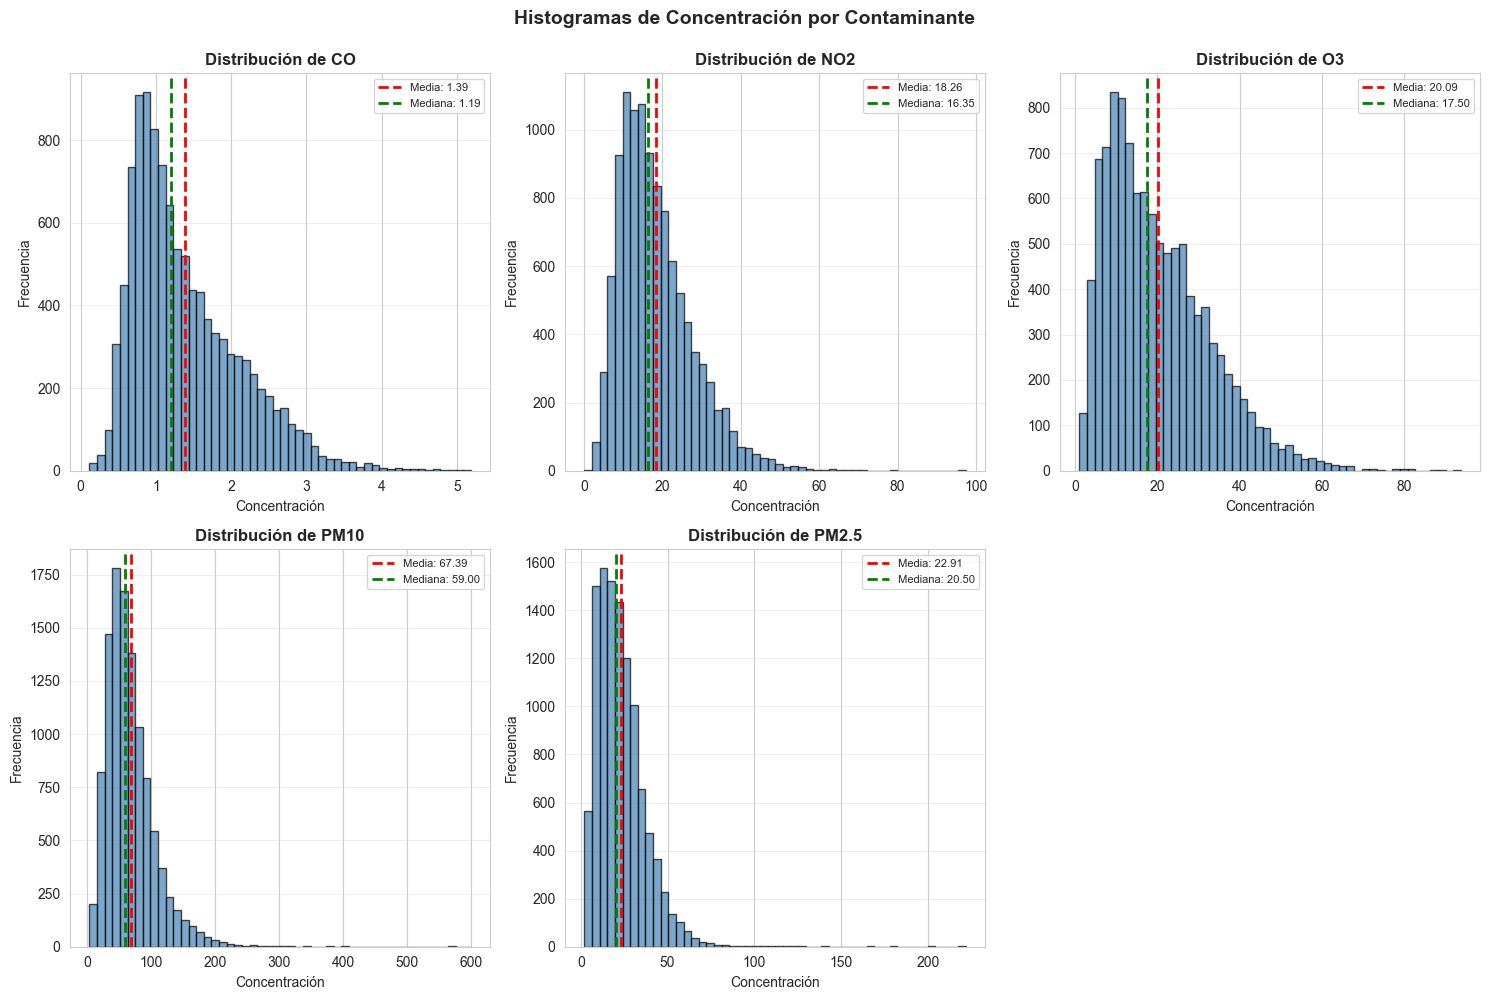

In [35]:
parametros = df['parametro'].unique()
n_params = len(parametros)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, param in enumerate(sorted(parametros)):
    data = df[df['parametro'] == param]['valor']
    
    axes[idx].hist(data, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Distribución de {param}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Concentración', fontsize=10)
    axes[idx].set_ylabel('Frecuencia', fontsize=10)
    axes[idx].grid(axis='y', alpha=0.3)
    
    # Añadir estadísticas
    media = data.mean()
    mediana = data.median()
    axes[idx].axvline(media, color='red', linestyle='--', linewidth=2, label=f'Media: {media:.2f}')
    axes[idx].axvline(mediana, color='green', linestyle='--', linewidth=2, label=f'Mediana: {mediana:.2f}')
    axes[idx].legend(fontsize=8)

# Ocultar ejes extras si hay menos de 6 parámetros
for idx in range(n_params, len(axes)):
    axes[idx].axis('off')

plt.suptitle('Histogramas de Concentración por Contaminante', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

### 12.2 Boxplot: Valor vs Franja Horaria

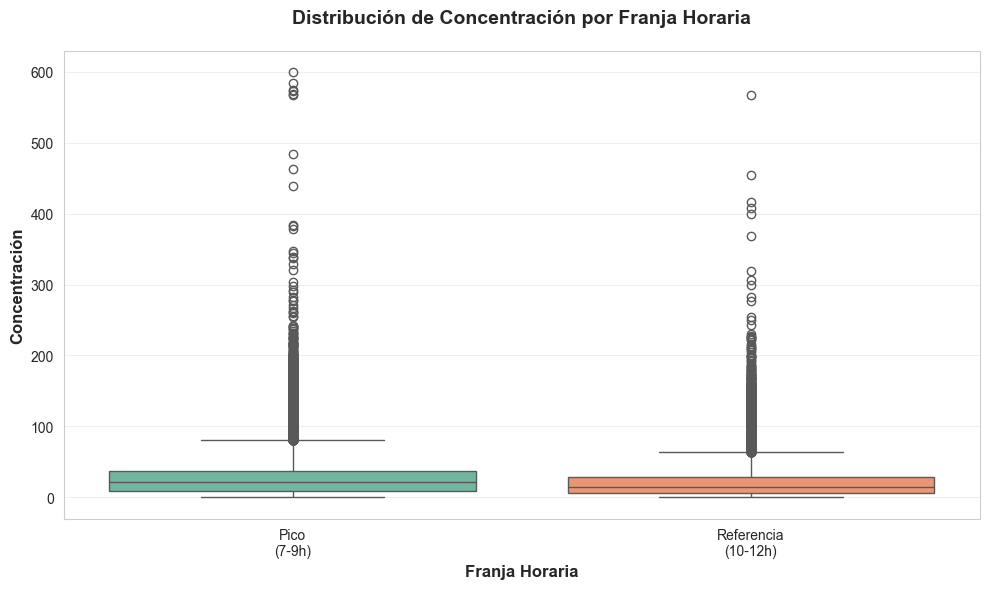

In [36]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(data=df, x='franja_horaria', y='valor', palette='Set2', ax=ax)

ax.set_title('Distribución de Concentración por Franja Horaria', fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Franja Horaria', fontsize=12, fontweight='bold')
ax.set_ylabel('Concentración', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Etiquetas más descriptivas
etiquetas = ['Pico\n(7-9h)', 'Referencia\n(10-12h)']
ax.set_xticklabels(etiquetas)

plt.tight_layout()
plt.show()

### 12.3 Boxplot: Valor vs Clase

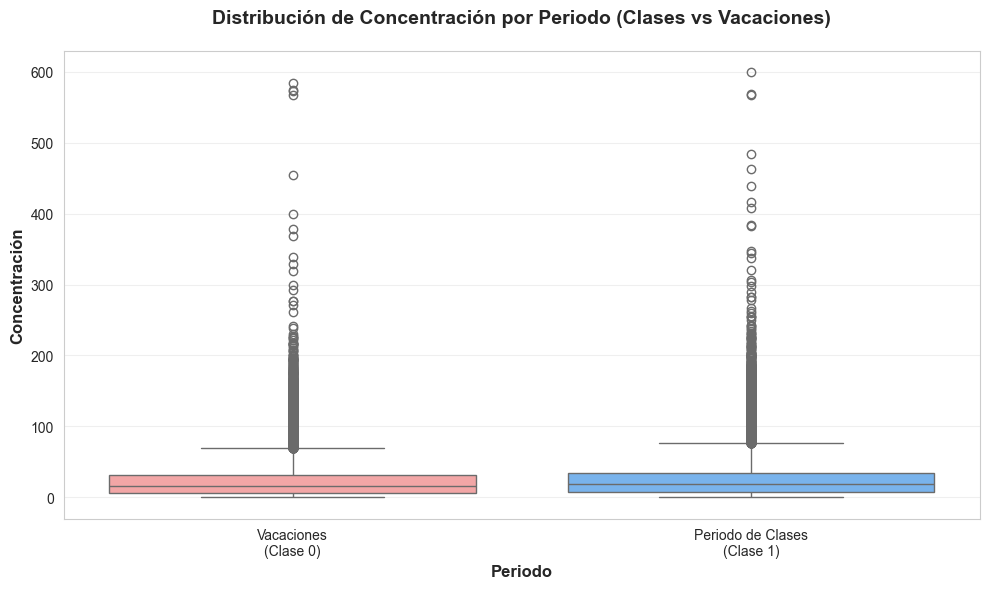

In [37]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(data=df, x='clase', y='valor', palette=['#ff9999', '#66b3ff'], ax=ax)

ax.set_title('Distribución de Concentración por Periodo (Clases vs Vacaciones)', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Periodo', fontsize=12, fontweight='bold')
ax.set_ylabel('Concentración', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Etiquetas descriptivas
ax.set_xticklabels(['Vacaciones\n(Clase 0)', 'Periodo de Clases\n(Clase 1)'])

plt.tight_layout()
plt.show()

### 12.4 Boxplot: Valor por Estación

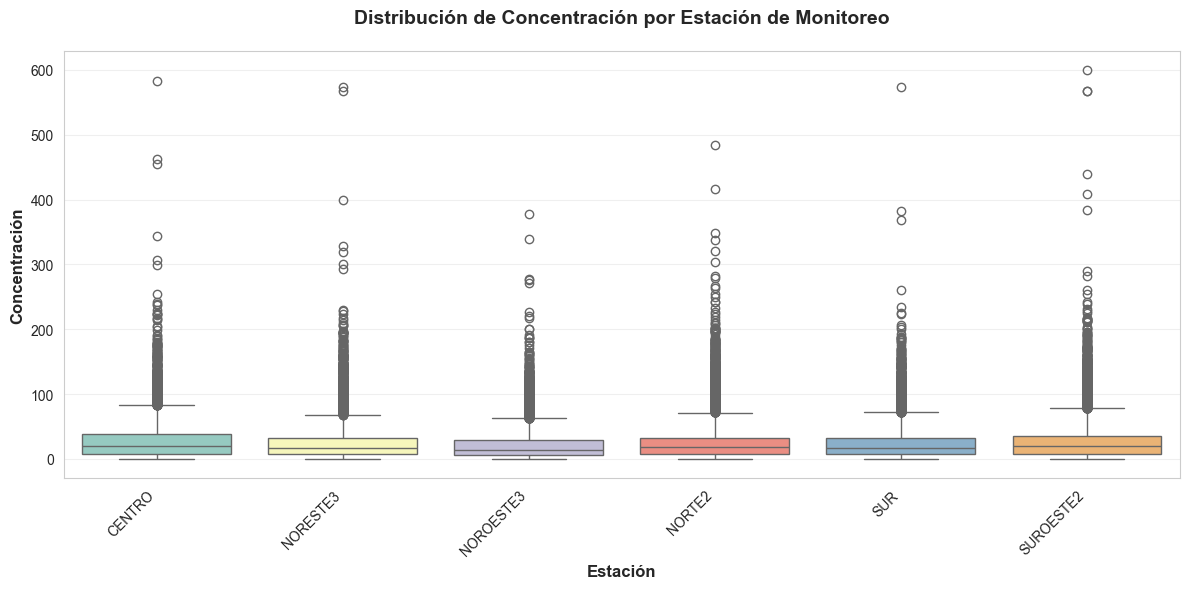

In [38]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.boxplot(data=df, x='estacion', y='valor', palette='Set3', ax=ax)

ax.set_title('Distribución de Concentración por Estación de Monitoreo', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Estación', fontsize=12, fontweight='bold')
ax.set_ylabel('Concentración', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 12.5 Boxplot: Contaminante × Franja × Clase

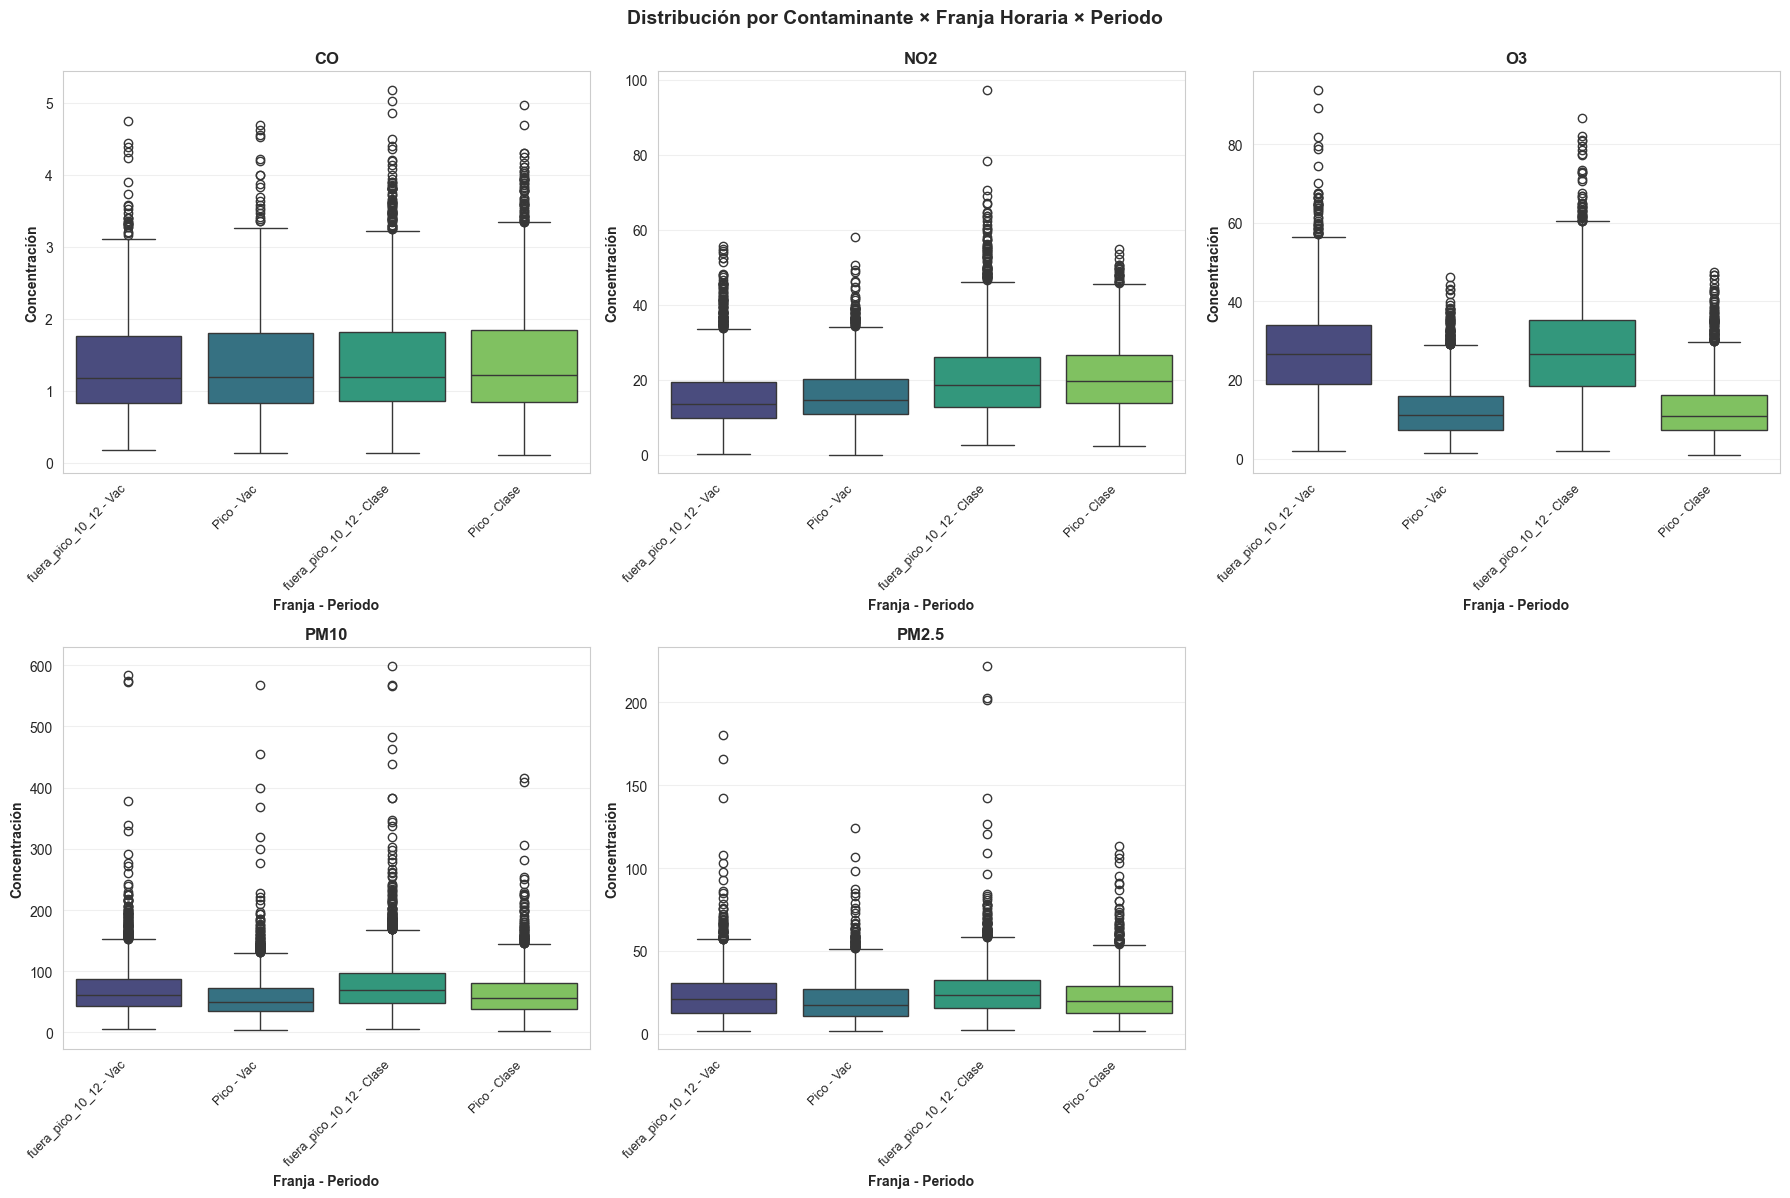

In [39]:
# Crear una columna combinada para mejor visualización
df['franja_clase'] = df['franja_horaria'].str.replace('pico_7_9', 'Pico').str.replace('ref_10_12', 'Ref') + \
                     ' - ' + df['clase'].map({0: 'Vac', 1: 'Clase'})

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

parametros_sorted = sorted(df['parametro'].unique())

for idx, param in enumerate(parametros_sorted):
    data_param = df[df['parametro'] == param]
    
    sns.boxplot(data=data_param, x='franja_clase', y='valor', 
                palette='viridis', ax=axes[idx])
    
    axes[idx].set_title(f'{param}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Franja - Periodo', fontsize=10, fontweight='bold')
    axes[idx].set_ylabel('Concentración', fontsize=10, fontweight='bold')
    axes[idx].grid(axis='y', alpha=0.3)
    axes[idx].tick_params(axis='x', rotation=45)
    
    # Ajustar etiquetas del eje x
    axes[idx].set_xticklabels(axes[idx].get_xticklabels(), rotation=45, ha='right', fontsize=9)

# Ocultar ejes extras
for idx in range(len(parametros_sorted), len(axes)):
    axes[idx].axis('off')

plt.suptitle('Distribución por Contaminante × Franja Horaria × Periodo', 
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

# Eliminar columna temporal
df.drop(columns=['franja_clase'], inplace=True)

### 12.6 Diagramas de barras

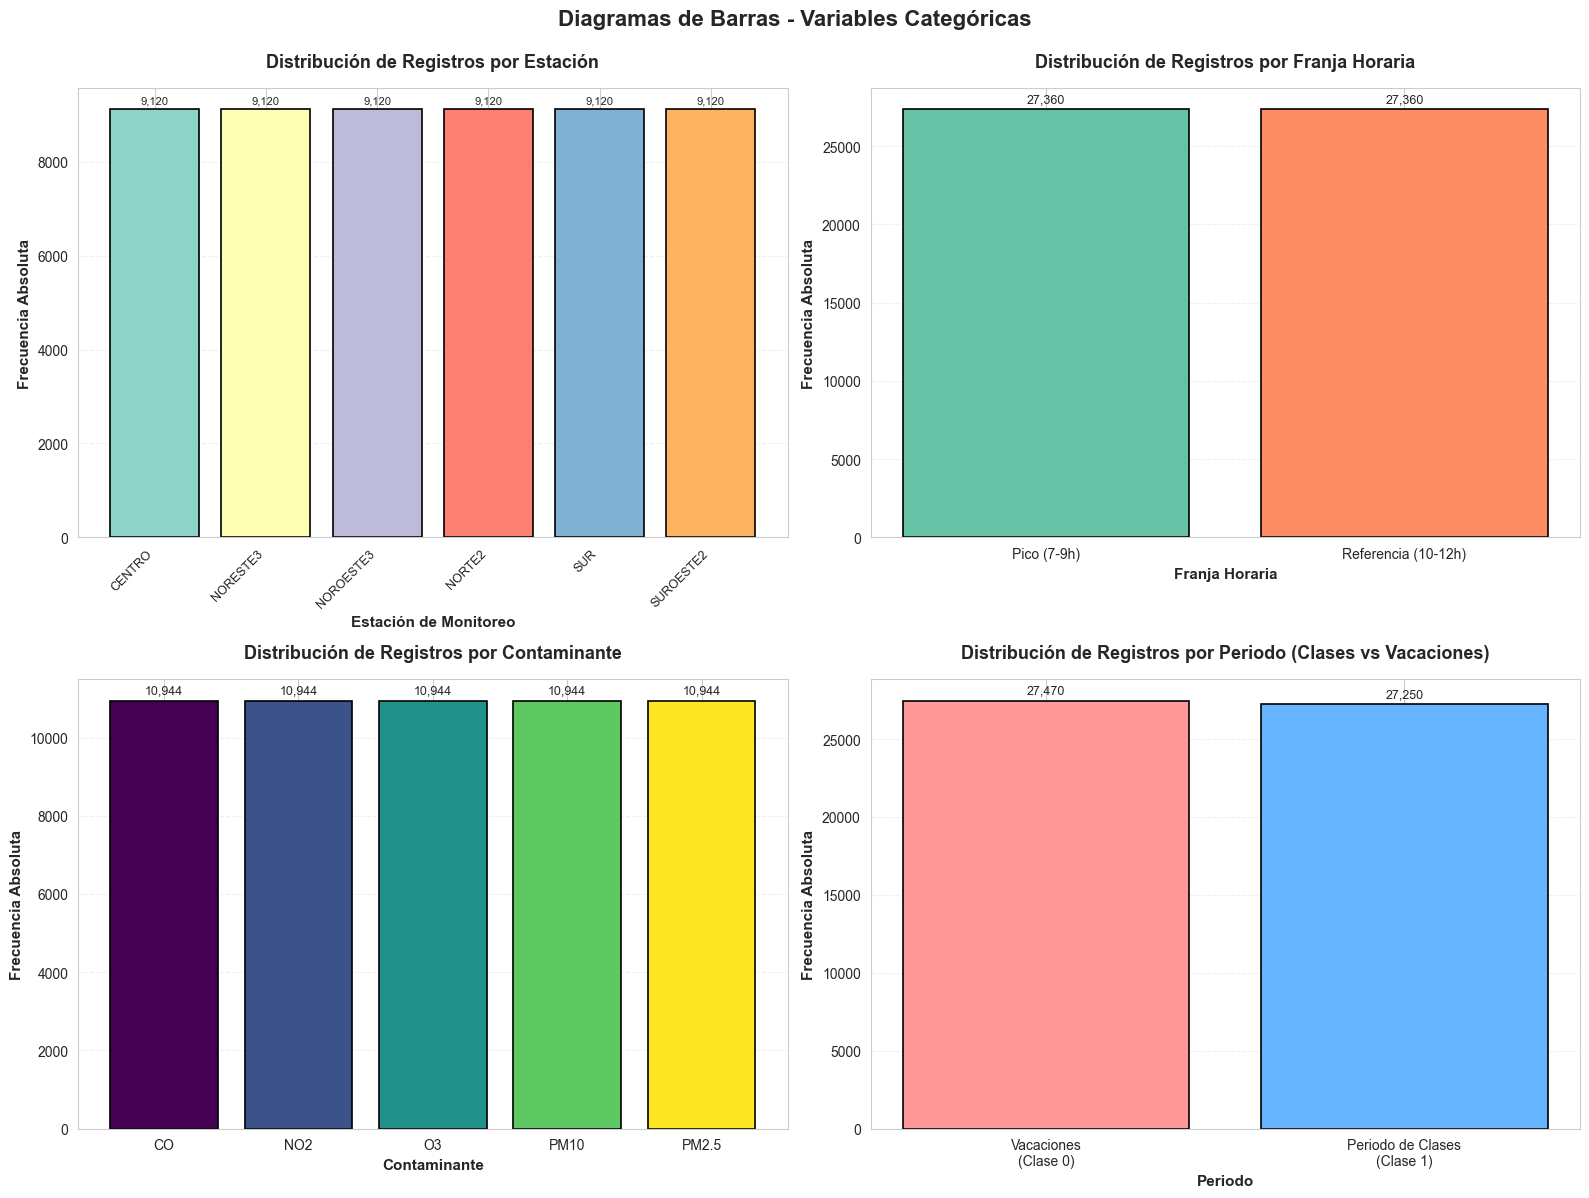

In [40]:
# Crear figura con subplots para diagramas de barras
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Frecuencia por Estación
ax1 = axes[0, 0]
freq_est = df['estacion'].value_counts().sort_index()
colors_est = plt.cm.Set3(range(len(freq_est)))
ax1.bar(range(len(freq_est)), freq_est.values, color=colors_est, edgecolor='black', linewidth=1.2)
ax1.set_xticks(range(len(freq_est)))
ax1.set_xticklabels(freq_est.index, rotation=45, ha='right', fontsize=9)
ax1.set_ylabel('Frecuencia Absoluta', fontsize=11, fontweight='bold')
ax1.set_xlabel('Estación de Monitoreo', fontsize=11, fontweight='bold')
ax1.set_title('Distribución de Registros por Estación', fontsize=13, fontweight='bold', pad=15)
ax1.grid(axis='y', alpha=0.3, linestyle='--')
# Añadir valores encima de las barras
for i, v in enumerate(freq_est.values):
    ax1.text(i, v + max(freq_est.values)*0.01, f'{v:,}', ha='center', va='bottom', fontsize=8)

# 2. Frecuencia por Franja Horaria
ax2 = axes[0, 1]
freq_franja_plot = df['franja_horaria'].value_counts().sort_index()
colors_franja = ['#66c2a5', '#fc8d62']
ax2.bar(range(len(freq_franja_plot)), freq_franja_plot.values, color=colors_franja, edgecolor='black', linewidth=1.2)
ax2.set_xticks(range(len(freq_franja_plot)))
etiquetas_franja = ['Pico (7-9h)', 'Referencia (10-12h)']
ax2.set_xticklabels(etiquetas_franja, fontsize=10)
ax2.set_ylabel('Frecuencia Absoluta', fontsize=11, fontweight='bold')
ax2.set_xlabel('Franja Horaria', fontsize=11, fontweight='bold')
ax2.set_title('Distribución de Registros por Franja Horaria', fontsize=13, fontweight='bold', pad=15)
ax2.grid(axis='y', alpha=0.3, linestyle='--')
for i, v in enumerate(freq_franja_plot.values):
    ax2.text(i, v + max(freq_franja_plot.values)*0.01, f'{v:,}', ha='center', va='bottom', fontsize=9)

# 3. Frecuencia por Parámetro (Contaminante)
ax3 = axes[1, 0]
freq_param = df['parametro'].value_counts().sort_index()
colors_param = plt.cm.viridis(np.linspace(0, 1, len(freq_param)))
ax3.bar(range(len(freq_param)), freq_param.values, color=colors_param, edgecolor='black', linewidth=1.2)
ax3.set_xticks(range(len(freq_param)))
ax3.set_xticklabels(freq_param.index, fontsize=10)
ax3.set_ylabel('Frecuencia Absoluta', fontsize=11, fontweight='bold')
ax3.set_xlabel('Contaminante', fontsize=11, fontweight='bold')
ax3.set_title('Distribución de Registros por Contaminante', fontsize=13, fontweight='bold', pad=15)
ax3.grid(axis='y', alpha=0.3, linestyle='--')
for i, v in enumerate(freq_param.values):
    ax3.text(i, v + max(freq_param.values)*0.01, f'{v:,}', ha='center', va='bottom', fontsize=9)

# 4. Frecuencia por Clase
ax4 = axes[1, 1]
freq_clase_plot = df['clase'].value_counts().sort_index()
colors_clase = ['#ff9999', '#66b3ff']
ax4.bar(range(len(freq_clase_plot)), freq_clase_plot.values, color=colors_clase, edgecolor='black', linewidth=1.2)
ax4.set_xticks(range(len(freq_clase_plot)))
etiquetas_clase = ['Vacaciones\n(Clase 0)', 'Periodo de Clases\n(Clase 1)']
ax4.set_xticklabels(etiquetas_clase, fontsize=10)
ax4.set_ylabel('Frecuencia Absoluta', fontsize=11, fontweight='bold')
ax4.set_xlabel('Periodo', fontsize=11, fontweight='bold')
ax4.set_title('Distribución de Registros por Periodo (Clases vs Vacaciones)', fontsize=13, fontweight='bold', pad=15)
ax4.grid(axis='y', alpha=0.3, linestyle='--')
for i, v in enumerate(freq_clase_plot.values):
    ax4.text(i, v + max(freq_clase_plot.values)*0.01, f'{v:,}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Diagramas de Barras - Variables Categóricas', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

### 12.6 Diagramas de pastel

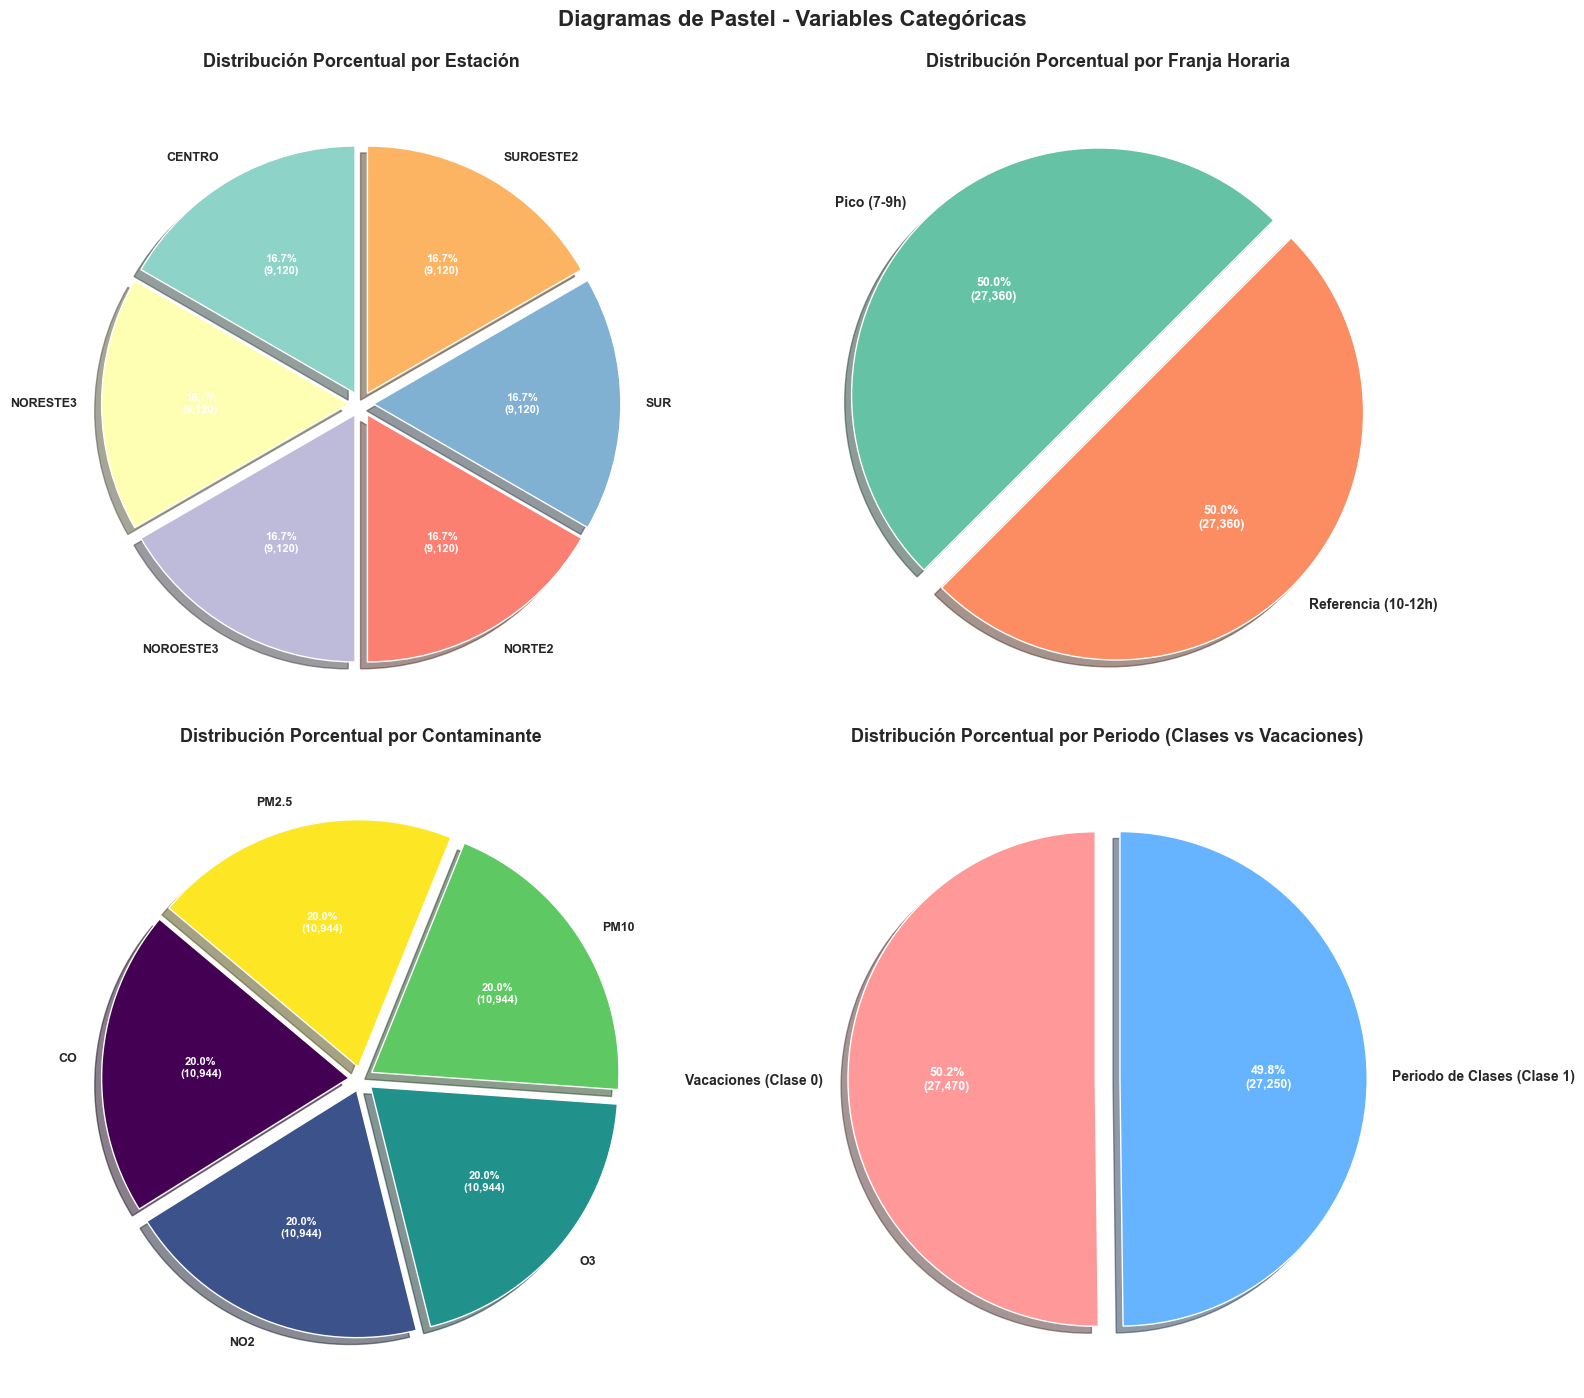

In [41]:
# Crear figura con subplots para diagramas de pastel
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# Configuración de estilo para pasteles
def autopct_format(values):
    def my_format(pct):
        total = sum(values)
        val = int(round(pct*total/100.0))
        return f'{pct:.1f}%\n({val:,})' if pct > 2 else ''
    return my_format

# 1. Distribución por Estación
ax1 = axes[0, 0]
freq_est = df['estacion'].value_counts().sort_index()
colors_est = plt.cm.Set3(range(len(freq_est)))
wedges, texts, autotexts = ax1.pie(freq_est.values, 
                                     labels=freq_est.index, 
                                     autopct=autopct_format(freq_est.values),
                                     colors=colors_est,
                                     startangle=90,
                                     explode=[0.05]*len(freq_est),  # Separar ligeramente
                                     shadow=True,
                                     textprops={'fontsize': 9, 'fontweight': 'bold'})
ax1.set_title('Distribución Porcentual por Estación', fontsize=13, fontweight='bold', pad=20)
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(8)

# 2. Distribución por Franja Horaria
ax2 = axes[0, 1]
freq_franja_plot = df['franja_horaria'].value_counts().sort_index()
colors_franja = ['#66c2a5', '#fc8d62']
etiquetas_franja = ['Pico (7-9h)', 'Referencia (10-12h)']
wedges, texts, autotexts = ax2.pie(freq_franja_plot.values, 
                                     labels=etiquetas_franja,
                                     autopct=autopct_format(freq_franja_plot.values),
                                     colors=colors_franja,
                                     startangle=45,
                                     explode=[0.05, 0.05],
                                     shadow=True,
                                     textprops={'fontsize': 10, 'fontweight': 'bold'})
ax2.set_title('Distribución Porcentual por Franja Horaria', fontsize=13, fontweight='bold', pad=20)
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(9)

# 3. Distribución por Contaminante
ax3 = axes[1, 0]
freq_param = df['parametro'].value_counts().sort_index()
colors_param = plt.cm.viridis(np.linspace(0, 1, len(freq_param)))
wedges, texts, autotexts = ax3.pie(freq_param.values, 
                                     labels=freq_param.index,
                                     autopct=autopct_format(freq_param.values),
                                     colors=colors_param,
                                     startangle=140,
                                     explode=[0.05]*len(freq_param),
                                     shadow=True,
                                     textprops={'fontsize': 9, 'fontweight': 'bold'})
ax3.set_title('Distribución Porcentual por Contaminante', fontsize=13, fontweight='bold', pad=20)
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(8)

# 4. Distribución por Clase
ax4 = axes[1, 1]
freq_clase_plot = df['clase'].value_counts().sort_index()
colors_clase = ['#ff9999', '#66b3ff']
etiquetas_clase = ['Vacaciones (Clase 0)', 'Periodo de Clases (Clase 1)']
wedges, texts, autotexts = ax4.pie(freq_clase_plot.values, 
                                     labels=etiquetas_clase,
                                     autopct=autopct_format(freq_clase_plot.values),
                                     colors=colors_clase,
                                     startangle=90,
                                     explode=[0.05, 0.05],
                                     shadow=True,
                                     textprops={'fontsize': 10, 'fontweight': 'bold'})
ax4.set_title('Distribución Porcentual por Periodo (Clases vs Vacaciones)', fontsize=13, fontweight='bold', pad=20)
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(9)

plt.suptitle('Diagramas de Pastel - Variables Categóricas', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

## 13. Análisis de correlación entre contaminantes

### 13.1 Tabla pivot: Date × Contaminantes

In [42]:
# Crear tabla pivot: filas = date, columnas = parametro, valores = promedio de valor
pivot_contaminantes = df.pivot_table(
    index='date', 
    columns='parametro', 
    values='valor', 
    aggfunc='mean'
)

print("=" * 70)
print("TABLA PIVOT: FECHA × CONTAMINANTES")
print("=" * 70)
print(f"Forma de la tabla: {pivot_contaminantes.shape}")
print(f"Fechas únicas: {len(pivot_contaminantes)}")
print(f"Contaminantes: {list(pivot_contaminantes.columns)}")
print("=" * 70)
print("\nPrimeras 10 filas:")
print(pivot_contaminantes.head(10))
print("\nÚltimas 10 filas:")
print(pivot_contaminantes.tail(10))
print("=" * 70)

TABLA PIVOT: FECHA × CONTAMINANTES
Forma de la tabla: (912, 5)
Fechas únicas: 912
Contaminantes: ['CO', 'NO2', 'O3', 'PM10', 'PM2.5']

Primeras 10 filas:
parametro         CO        NO2         O3        PM10      PM2.5
date                                                             
2023-01-01  1.323528  20.407639  16.162500   77.770833  33.239861
2023-01-02  1.447896  27.753472   9.635417   90.295139  25.452014
2023-01-03  1.091833  21.279861  15.518750   87.159722  11.440556
2023-01-04  1.532500  34.421528  11.450694  135.347222  25.983750
2023-01-05  1.464646  40.495486  11.584028  122.760417  30.691015
2023-01-06  1.159049  21.178819  12.192361   91.309028  35.629583
2023-01-07  1.463326  29.098958  10.250000  101.967431  34.270625
2023-01-08  1.081806  15.550000  15.910417   52.974236  18.569725
2023-01-09  1.212938  24.615625  15.788889   62.026319  21.529541
2023-01-10  1.794618  37.302431   9.663194  130.045556  41.622361

Últimas 10 filas:
parametro         CO        NO2    

### 13.2 Matriz de correlación entre contaminantes

In [43]:
# Calcular matriz de correlación
contaminantes_interes = ['CO', 'NO2', 'PM10', 'PM2.5', 'O3']
correlacion = pivot_contaminantes[contaminantes_interes].corr()

print("=" * 70)
print("MATRIZ DE CORRELACIÓN ENTRE CONTAMINANTES")
print("=" * 70)
print(correlacion.round(3))
print("=" * 70)

# Estadísticas de la correlación
print("\nEstadísticas de correlación:")
print(f"  • Correlación promedio: {correlacion.values[np.triu_indices_from(correlacion.values, k=1)].mean():.3f}")
print(f"  • Correlación máxima: {correlacion.values[np.triu_indices_from(correlacion.values, k=1)].max():.3f}")
print(f"  • Correlación mínima: {correlacion.values[np.triu_indices_from(correlacion.values, k=1)].min():.3f}")

# Pares con mayor correlación
print("\nPares con mayor correlación:")
corr_pairs = []
for i in range(len(correlacion.columns)):
    for j in range(i+1, len(correlacion.columns)):
        corr_pairs.append((correlacion.columns[i], correlacion.columns[j], correlacion.iloc[i, j]))
corr_pairs_sorted = sorted(corr_pairs, key=lambda x: abs(x[2]), reverse=True)
for par1, par2, corr_val in corr_pairs_sorted[:5]:
    print(f"  • {par1} - {par2}: {corr_val:.3f}")

MATRIZ DE CORRELACIÓN ENTRE CONTAMINANTES
parametro     CO    NO2   PM10  PM2.5     O3
parametro                                   
CO         1.000  0.473  0.431  0.460 -0.165
NO2        0.473  1.000  0.632  0.487 -0.240
PM10       0.431  0.632  1.000  0.744 -0.037
PM2.5      0.460  0.487  0.744  1.000 -0.071
O3        -0.165 -0.240 -0.037 -0.071  1.000

Estadísticas de correlación:
  • Correlación promedio: 0.271
  • Correlación máxima: 0.744
  • Correlación mínima: -0.240

Pares con mayor correlación:
  • PM10 - PM2.5: 0.744
  • NO2 - PM10: 0.632
  • NO2 - PM2.5: 0.487
  • CO - NO2: 0.473
  • CO - PM2.5: 0.460


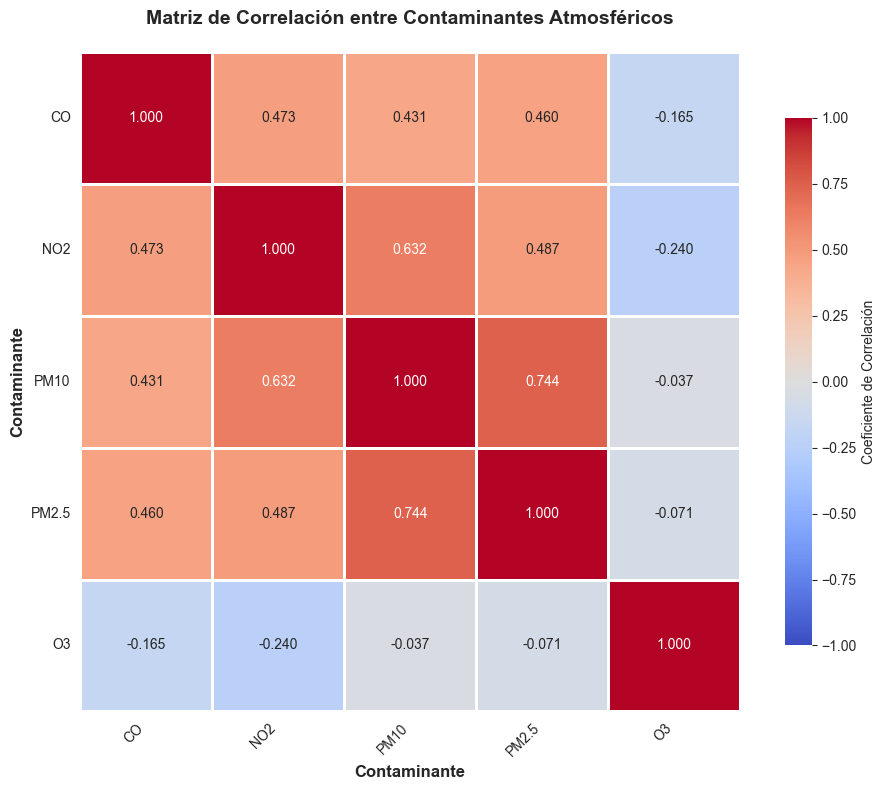

In [44]:
fig, ax = plt.subplots(figsize=(10, 8))

# Crear heatmap con anotaciones
sns.heatmap(correlacion, 
            annot=True,  # Mostrar valores
            fmt='.3f',   # Formato con 3 decimales
            cmap='coolwarm',  # Esquema de colores
            center=0,    # Centrar en 0
            square=True,  # Celdas cuadradas
            linewidths=1,  # Líneas entre celdas
            cbar_kws={'label': 'Coeficiente de Correlación', 'shrink': 0.8},
            vmin=-1, 
            vmax=1,
            ax=ax)

ax.set_title('Matriz de Correlación entre Contaminantes Atmosféricos', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Contaminante', fontsize=12, fontweight='bold')
ax.set_ylabel('Contaminante', fontsize=12, fontweight='bold')

# Rotar etiquetas para mejor legibilidad
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

## 14. Correlación entre franjas horarias (7-9h vs 10-12h)

CORRELACIÓN: FRANJA 7-9h vs 10-12h

Correlación general: nan
✗ DÉBIL: Franjas independientes


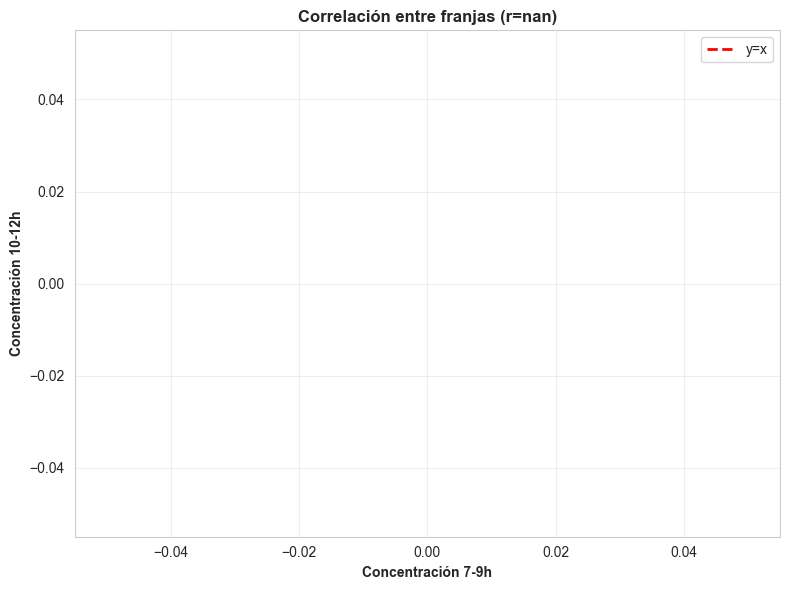

In [45]:
# Muestra aleatoria para acelerar
df_sample = df.sample(n=min(10000, len(df)), random_state=42).copy()
df_sample['fecha_dia'] = df_sample['date'].dt.date

# Agrupar por franja
pico = df_sample[df_sample['franja_horaria'] == 'pico_7_9'].groupby(['fecha_dia', 'estacion', 'parametro'])['valor'].mean()
ref = df_sample[df_sample['franja_horaria'] == 'ref_10_12'].groupby(['fecha_dia', 'estacion', 'parametro'])['valor'].mean()

# Unir
datos = pd.DataFrame({'pico': pico, 'ref': ref}).dropna()

# Correlación por contaminante
print("=" * 60)
print("CORRELACIÓN: FRANJA 7-9h vs 10-12h")
print("=" * 60)

for param in df['parametro'].unique():
    mask = datos.index.get_level_values('parametro') == param
    if mask.sum() > 0:
        r = datos[mask]['pico'].corr(datos[mask]['ref'])
        print(f"{param:8s}  r = {r:.3f}")

# Correlación general
r_total = datos['pico'].corr(datos['ref'])
print("\n" + "=" * 60)
print(f"Correlación general: {r_total:.3f}")
if r_total >= 0.7:
    print("✓ FUERTE: 7-9h predicen bien 10-12h")
elif r_total >= 0.3:
    print("≈ MODERADA: Relación con variabilidad")
else:
    print("✗ DÉBIL: Franjas independientes")
print("=" * 60)

# Gráfico scatter
fig, ax = plt.subplots(figsize=(8, 6))
sample_plot = datos.sample(n=min(500, len(datos)), random_state=42)
ax.scatter(sample_plot['pico'], sample_plot['ref'], alpha=0.3, s=20)
ax.plot([datos['pico'].min(), datos['pico'].max()], 
        [datos['pico'].min(), datos['pico'].max()], 
        'r--', lw=2, label='y=x')
ax.set_xlabel('Concentración 7-9h', fontweight='bold')
ax.set_ylabel('Concentración 10-12h', fontweight='bold')
ax.set_title(f'Correlación entre franjas (r={r_total:.3f})', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 14.1 Prueba de LJUNG-BOX

In [46]:
from scipy import stats as scipy_stats
from statsmodels.stats.diagnostic import acorr_ljungbox

print("=" * 80)
print("PRUEBA DE LJUNG-BOX PARA AUTOCORRELACIÓN")
print("=" * 80)
print("\nObjetivo: Detectar autocorrelación en la serie temporal de concentraciones")
print("H0: No existe autocorrelación significativa en la serie")
print("H1: Existe autocorrelación significativa en la serie")
print("=" * 80)

# Crear serie temporal agregada por día (promedio de todas las estaciones y contaminantes)
serie_diaria_pico = df_pico.groupby('date')['valor'].mean().sort_index()

print(f"\nSerie temporal analizada:")
print(f"  • Periodo: {serie_diaria_pico.index.min()} a {serie_diaria_pico.index.max()}")
print(f"  • Observaciones: {len(serie_diaria_pico):,}")
print(f"  • Frecuencia: Diaria")
print(f"  • Promedio: {serie_diaria_pico.mean():.2f}")
print(f"  • Desv. Estándar: {serie_diaria_pico.std():.2f}")

# Aplicar prueba de Ljung-Box con diferentes rezagos
lags = [1, 5, 10, 15, 20, 30]
print("\n" + "=" * 80)
print("RESULTADOS DE LA PRUEBA DE LJUNG-BOX")
print("=" * 80)

resultados_ljungbox = []

for lag in lags:
    if lag < len(serie_diaria_pico):
        lb_result = acorr_ljungbox(serie_diaria_pico, lags=[lag], return_df=True)
        lb_stat = lb_result['lb_stat'].iloc[0]
        p_value = lb_result['lb_pvalue'].iloc[0]
        
        resultado = {
            'Rezago': lag,
            'Estadístico LB': round(lb_stat, 4),
            'p-valor': round(p_value, 4),
            'Decisión (α=0.05)': 'Rechazar H0' if p_value < 0.05 else 'No rechazar H0',
            'Interpretación': 'Autocorrelación significativa' if p_value < 0.05 else 'No hay autocorrelación significativa'
        }
        resultados_ljungbox.append(resultado)

# Crear DataFrame con resultados
df_ljungbox = pd.DataFrame(resultados_ljungbox)
print(df_ljungbox.to_string(index=False))
print("=" * 80)

# Interpretación general
autocorr_count = sum(1 for r in resultados_ljungbox if r['p-valor'] < 0.05)
print(f"\n INTERPRETACIÓN GENERAL:")
print(f"  • Rezagos con autocorrelación significativa: {autocorr_count}/{len(resultados_ljungbox)}")

if autocorr_count >= len(resultados_ljungbox) * 0.7:
    print("  • CONCLUSIÓN: Fuerte evidencia de autocorrelación en la serie temporal")
    print("  • Las concentraciones de contaminantes de un día están relacionadas con días anteriores")
elif autocorr_count >= len(resultados_ljungbox) * 0.3:
    print("  • CONCLUSIÓN: Evidencia moderada de autocorrelación en la serie temporal")
    print("  • Algunas concentraciones muestran dependencia temporal")
else:
    print("  • CONCLUSIÓN: Poca o ninguna evidencia de autocorrelación en la serie temporal")
    print("  • Las concentraciones diarias son relativamente independientes")


PRUEBA DE LJUNG-BOX PARA AUTOCORRELACIÓN

Objetivo: Detectar autocorrelación en la serie temporal de concentraciones
H0: No existe autocorrelación significativa en la serie
H1: Existe autocorrelación significativa en la serie

Serie temporal analizada:
  • Periodo: 2023-01-01 00:00:00 a 2025-06-30 00:00:00
  • Observaciones: 912
  • Frecuencia: Diaria
  • Promedio: 22.81
  • Desv. Estándar: 8.63

RESULTADOS DE LA PRUEBA DE LJUNG-BOX
 Rezago  Estadístico LB  p-valor Decisión (α=0.05)                Interpretación
      1        264.9107      0.0       Rechazar H0 Autocorrelación significativa
      5        481.7780      0.0       Rechazar H0 Autocorrelación significativa
     10        644.4549      0.0       Rechazar H0 Autocorrelación significativa
     15        739.3468      0.0       Rechazar H0 Autocorrelación significativa
     20        794.1222      0.0       Rechazar H0 Autocorrelación significativa
     30        893.8730      0.0       Rechazar H0 Autocorrelación significat

## 15. Análisis exploratorio  (7-9h)

### 15.1 Filtrar solo datos de franja  (7-9h)

In [47]:
# Filtrar solo la franja horaria de pico (7-9h)
df_pico = df[df['franja_horaria'] == 'pico_7_9'].copy()

print("=" * 80)
print("DATASET FILTRADO - SOLO FRANJA PICO (7-9h)")
print("=" * 80)
print(f"Total de registros originales:       {len(df):>15,}")
print(f"Registros en franja pico (7-9h):     {len(df_pico):>15,}")
print(f"Porcentaje del dataset original:     {(len(df_pico)/len(df)*100):>15.2f}%")
print("=" * 80)
print(f"\nColumnas: {df_pico.columns.tolist()}")
print(f"Rango de fechas: {df_pico['date'].min()} a {df_pico['date'].max()}")
print(f"Estaciones: {sorted(df_pico['estacion'].unique())}")
print(f"Contaminantes: {sorted(df_pico['parametro'].unique())}")
print("=" * 80)

DATASET FILTRADO - SOLO FRANJA PICO (7-9h)
Total de registros originales:                54,720
Registros en franja pico (7-9h):              27,360
Porcentaje del dataset original:               50.00%

Columnas: ['date', 'estacion', 'franja_horaria', 'clase', 'parametro', 'valor']
Rango de fechas: 2023-01-01 00:00:00 a 2025-06-30 00:00:00
Estaciones: ['CENTRO', 'NORESTE3', 'NOROESTE3', 'NORTE2', 'SUR', 'SUROESTE2']
Contaminantes: ['CO', 'NO2', 'O3', 'PM10', 'PM2.5']


### 15.2 Estadísticas descriptivas generales 

In [48]:
stats_pico_general = calcular_estadisticas_completas(df_pico['valor'])
stats_pico_general_df = pd.DataFrame(stats_pico_general, columns=['Estadístico - Pico 7-9h'])

print("=" * 70)
print("ESTADÍSTICAS DESCRIPTIVAS GENERALES - SOLO FRANJA PICO (7-9h)")
print("=" * 70)
print(stats_pico_general_df.to_string())
print("=" * 70)

ESTADÍSTICAS DESCRIPTIVAS GENERALES - SOLO FRANJA PICO (7-9h)
          Estadístico - Pico 7-9h
media                   22.809141
mediana                 14.883333
moda                     9.500000
minimo                   0.100000
maximo                 567.333333
rango                  567.233333
varianza               711.767220
desv_std                26.678966
Q1                       6.000000
Q2                      14.883333
Q3                      29.076250
IQR                     23.076250
n                    27360.000000


### 15.3 Estadísticas por estación 

In [49]:
stats_pico_estacion = df_pico.groupby('estacion')['valor'].apply(calcular_estadisticas_completas).unstack()

print("=" * 90)
print("ESTADÍSTICAS POR ESTACIÓN - SOLO FRANJA PICO (7-9h)")
print("=" * 90)
print(stats_pico_estacion.to_string())
print("=" * 90)

ESTADÍSTICAS POR ESTACIÓN - SOLO FRANJA PICO (7-9h)
               media    mediana   moda    minimo      maximo       rango    varianza   desv_std     Q1         Q2         Q3        IQR       n
estacion                                                                                                                                       
CENTRO     24.382394  17.000000  10.50  0.115000  454.200000  454.085000  706.745337  26.584682  6.000  17.000000  33.088750  27.088750  4560.0
NORESTE3   22.478719  15.000000  14.50  0.169500  567.333333  567.163833  741.765916  27.235380  7.100  15.000000  28.112500  21.012500  4560.0
NOROESTE3  19.898041  11.991667   5.00  0.100000  276.166667  276.066667  573.507729  23.948021  5.000  11.991667  23.922917  18.922917  4560.0
NORTE2     23.684994  15.000000  11.00  0.165000  416.000000  415.835000  841.860398  29.014831  6.000  15.000000  29.500000  23.500000  4560.0
SUR        21.723368  14.412500   6.00  0.197500  367.937500  367.740000  603.523993

### 15.4 Estadísticas por contaminante

In [50]:
stats_pico_parametro = df_pico.groupby('parametro')['valor'].apply(calcular_estadisticas_completas).unstack()

print("=" * 90)
print("ESTADÍSTICAS POR CONTAMINANTE - SOLO FRANJA PICO (7-9h)")
print("=" * 90)
print(stats_pico_parametro.to_string())
print("=" * 90)

ESTADÍSTICAS POR CONTAMINANTE - SOLO FRANJA PICO (7-9h)
               media    mediana    moda  minimo      maximo       rango     varianza   desv_std         Q1         Q2         Q3        IQR       n
parametro                                                                                                                                          
CO          1.393513   1.197500   0.825   0.115    4.975000    4.860000     0.520204   0.721252   0.833094   1.197500   1.820885   0.987792  5472.0
NO2        18.461564  16.900000  11.650   0.100   58.075000   57.975000    74.426856   8.627100  11.990625  16.900000  23.733333  11.742708  5472.0
O3         12.531632  10.891667  10.500   1.000   47.500000   46.500000    52.296056   7.231601   7.250000  10.891667  16.127083   8.877083  5472.0
PM10       60.486420  53.500000  35.000   3.000  567.333333  564.333333  1260.547904  35.504196  37.000000  53.500000  77.000000  40.000000  5472.0
PM2.5      21.172576  18.615000  11.000   2.000  124.100

### 15.5 Estadísticas por clase (periodo escolar)

In [51]:
stats_pico_clase = df_pico.groupby('clase')['valor'].apply(calcular_estadisticas_completas).unstack()

print("=" * 90)
print("ESTADÍSTICAS POR CLASE - SOLO FRANJA PICO (7-9h)")
print("=" * 90)
print("Clase 0 = Periodo fuera de clases / Vacaciones")
print("Clase 1 = Periodo de clases")
print("=" * 90)
print(stats_pico_clase.to_string())
print("=" * 90)

ESTADÍSTICAS POR CLASE - SOLO FRANJA PICO (7-9h)
Clase 0 = Periodo fuera de clases / Vacaciones
Clase 1 = Periodo de clases
           media  mediana  moda  minimo      maximo       rango    varianza   desv_std   Q1    Q2     Q3    IQR        n
clase                                                                                                                   
0      21.616973     13.9   6.0   0.100  567.333333  567.233333  666.464091  25.815966  6.0  13.9  27.00  21.00  13735.0
1      24.010933     16.0  10.5   0.115  416.000000  415.885000  754.611116  27.470186  6.0  16.0  30.75  24.75  13625.0


### 15.6 Estadísticas por estación × clase

In [52]:
stats_pico_est_clase = df_pico.groupby(['estacion', 'clase'])['valor'].apply(calcular_estadisticas_completas).unstack()

print("=" * 100)
print("ESTADÍSTICAS POR ESTACIÓN × CLASE - SOLO FRANJA PICO (7-9h)")
print("=" * 100)
print(stats_pico_est_clase.to_string())
print("=" * 100)

ESTADÍSTICAS POR ESTACIÓN × CLASE - SOLO FRANJA PICO (7-9h)
                     media    mediana  moda    minimo      maximo       rango    varianza   desv_std        Q1         Q2         Q3        IQR       n
estacion  clase                                                                                                                                        
CENTRO    0      23.926144  16.000000   9.0  0.133684  454.200000  454.066316  728.155539  26.984357  7.000000  16.000000  32.500000  25.500000  1565.0
          1      24.620802  17.745000   5.0  0.115000  307.000000  306.885000  695.631503  26.374827  6.000000  17.745000  33.500000  27.500000  2995.0
NORESTE3  0      22.478719  15.000000  14.5  0.169500  567.333333  567.163833  741.765916  27.235380  7.100000  15.000000  28.112500  21.012500  4560.0
NOROESTE3 0      19.898041  11.991667   5.0  0.100000  276.166667  276.066667  573.507729  23.948021  5.000000  11.991667  23.922917  18.922917  4560.0
NORTE2    0      20.736676  

### 15.7 Visualizaciones - Histogramas por contaminante

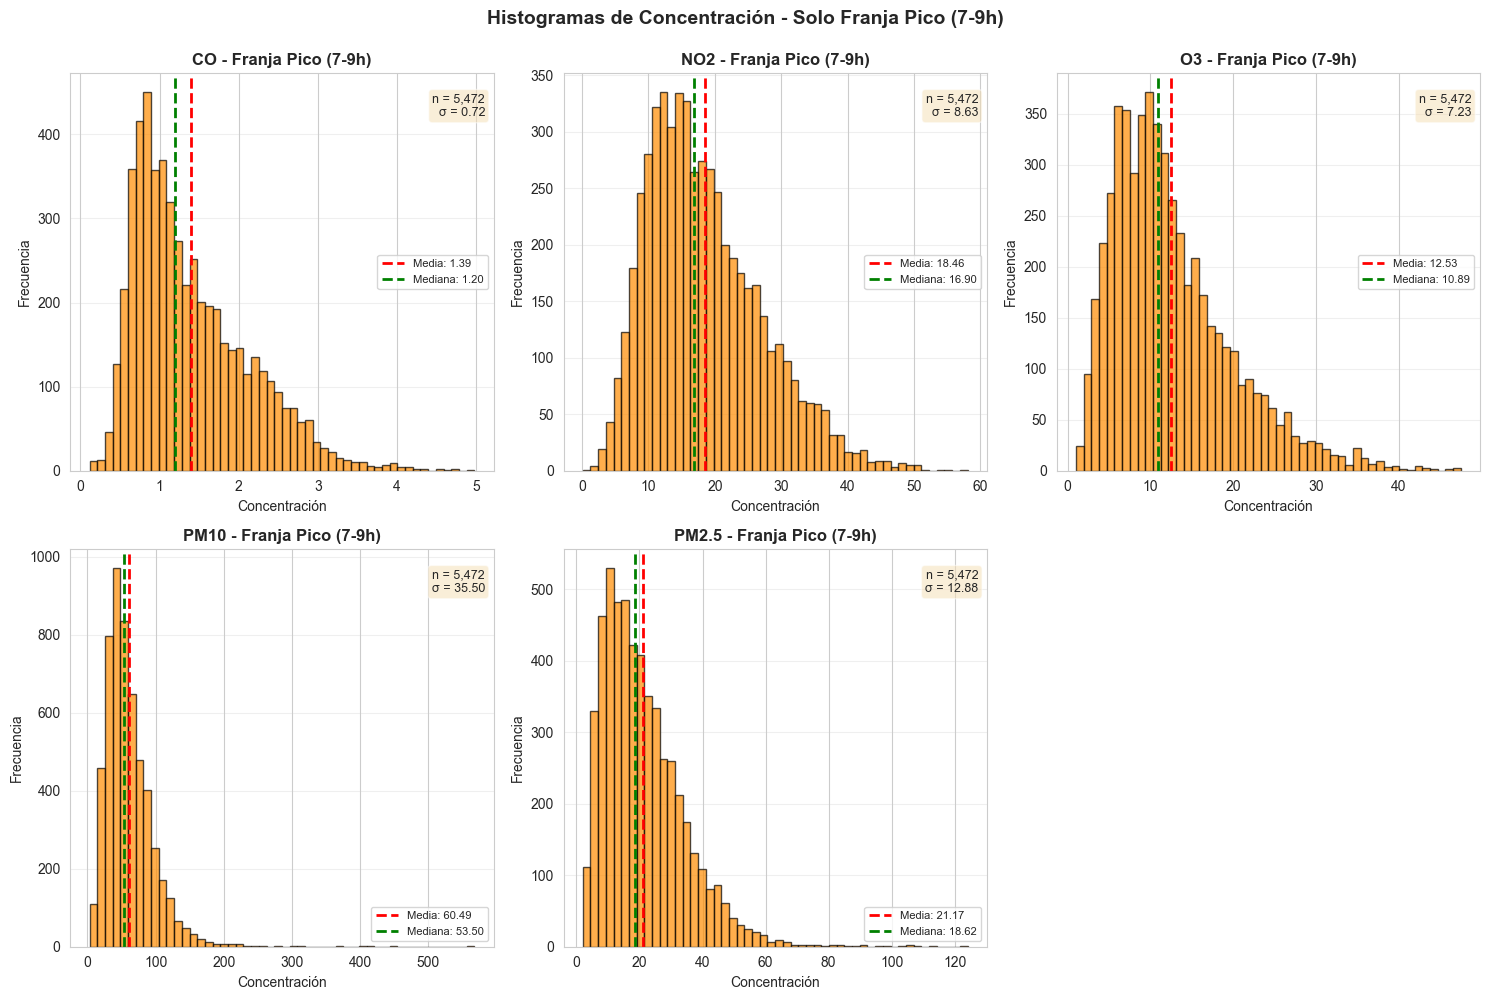

In [53]:
parametros_pico = df_pico['parametro'].unique()
n_params_pico = len(parametros_pico)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, param in enumerate(sorted(parametros_pico)):
    data = df_pico[df_pico['parametro'] == param]['valor']
    
    axes[idx].hist(data, bins=50, color='darkorange', edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'{param} - Franja Pico (7-9h)', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Concentración', fontsize=10)
    axes[idx].set_ylabel('Frecuencia', fontsize=10)
    axes[idx].grid(axis='y', alpha=0.3)
    
    # Estadísticas
    media = data.mean()
    mediana = data.median()
    desv = data.std()
    axes[idx].axvline(media, color='red', linestyle='--', linewidth=2, label=f'Media: {media:.2f}')
    axes[idx].axvline(mediana, color='green', linestyle='--', linewidth=2, label=f'Mediana: {mediana:.2f}')
    axes[idx].legend(fontsize=8)
    
    # Añadir n y desv std
    axes[idx].text(0.98, 0.95, f'n = {len(data):,}\nσ = {desv:.2f}', 
                   transform=axes[idx].transAxes, 
                   fontsize=9, 
                   verticalalignment='top',
                   horizontalalignment='right',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Ocultar ejes extras
for idx in range(n_params_pico, len(axes)):
    axes[idx].axis('off')

plt.suptitle('Histogramas de Concentración - Solo Franja Pico (7-9h)', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

### 15.8 Boxplot por estación

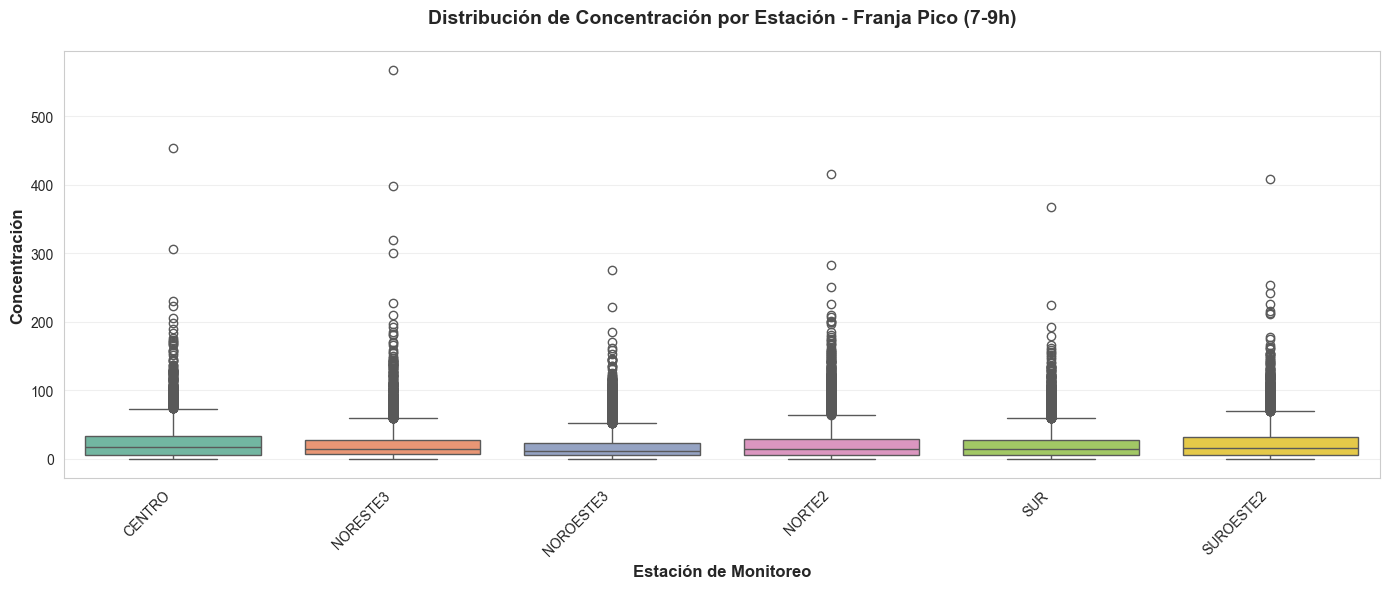

In [54]:
fig, ax = plt.subplots(figsize=(14, 6))

sns.boxplot(data=df_pico, x='estacion', y='valor', palette='Set2', ax=ax)

ax.set_title('Distribución de Concentración por Estación - Franja Pico (7-9h)', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Estación de Monitoreo', fontsize=12, fontweight='bold')
ax.set_ylabel('Concentración', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 15.9 Boxplot por contaminante

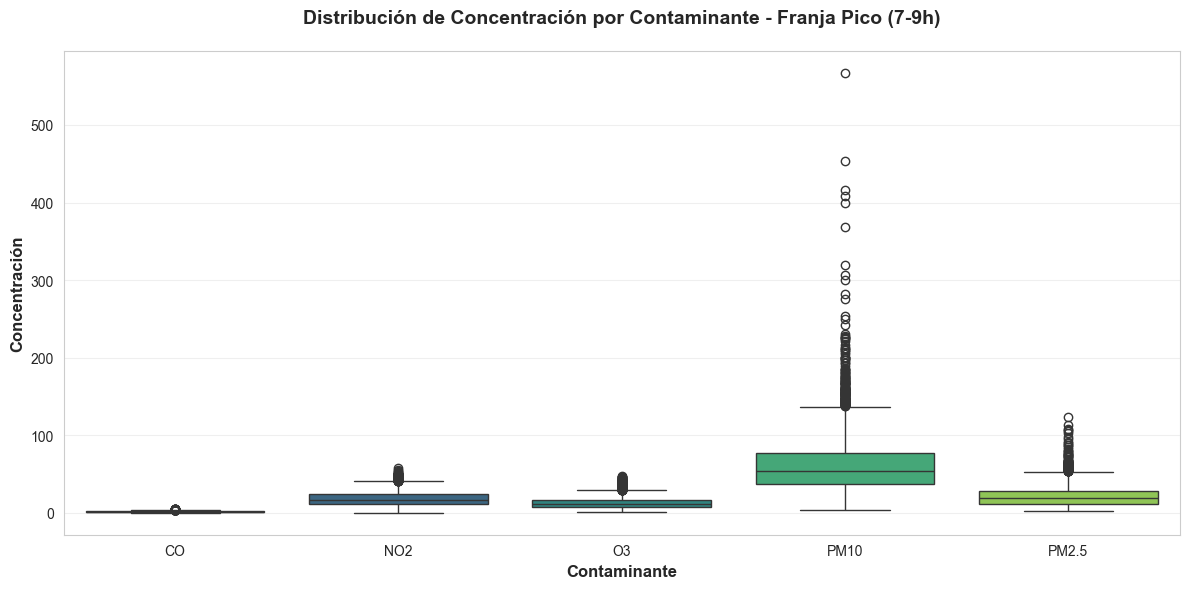

In [55]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.boxplot(data=df_pico, x='parametro', y='valor', palette='viridis', ax=ax)

ax.set_title('Distribución de Concentración por Contaminante - Franja Pico (7-9h)', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Contaminante', fontsize=12, fontweight='bold')
ax.set_ylabel('Concentración', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### 15.10 Boxplot por clase (periodo escolar)

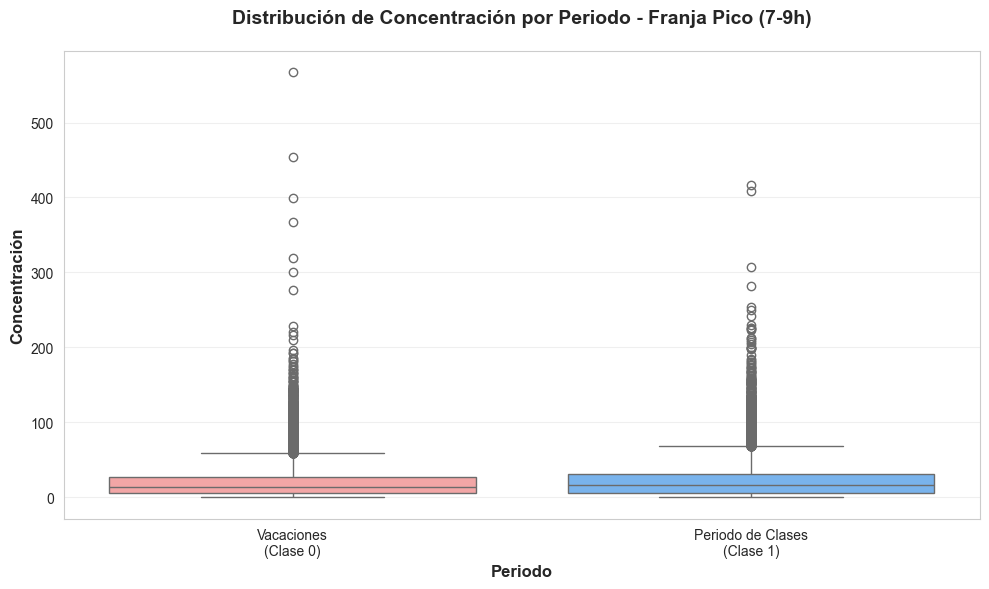

In [56]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(data=df_pico, x='clase', y='valor', palette=['#ff9999', '#66b3ff'], ax=ax)

ax.set_title('Distribución de Concentración por Periodo - Franja Pico (7-9h)', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Periodo', fontsize=12, fontweight='bold')
ax.set_ylabel('Concentración', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

ax.set_xticklabels(['Vacaciones\n(Clase 0)', 'Periodo de Clases\n(Clase 1)'])

plt.tight_layout()
plt.show()

### 15.11 Boxplot: Contaminante × Clase

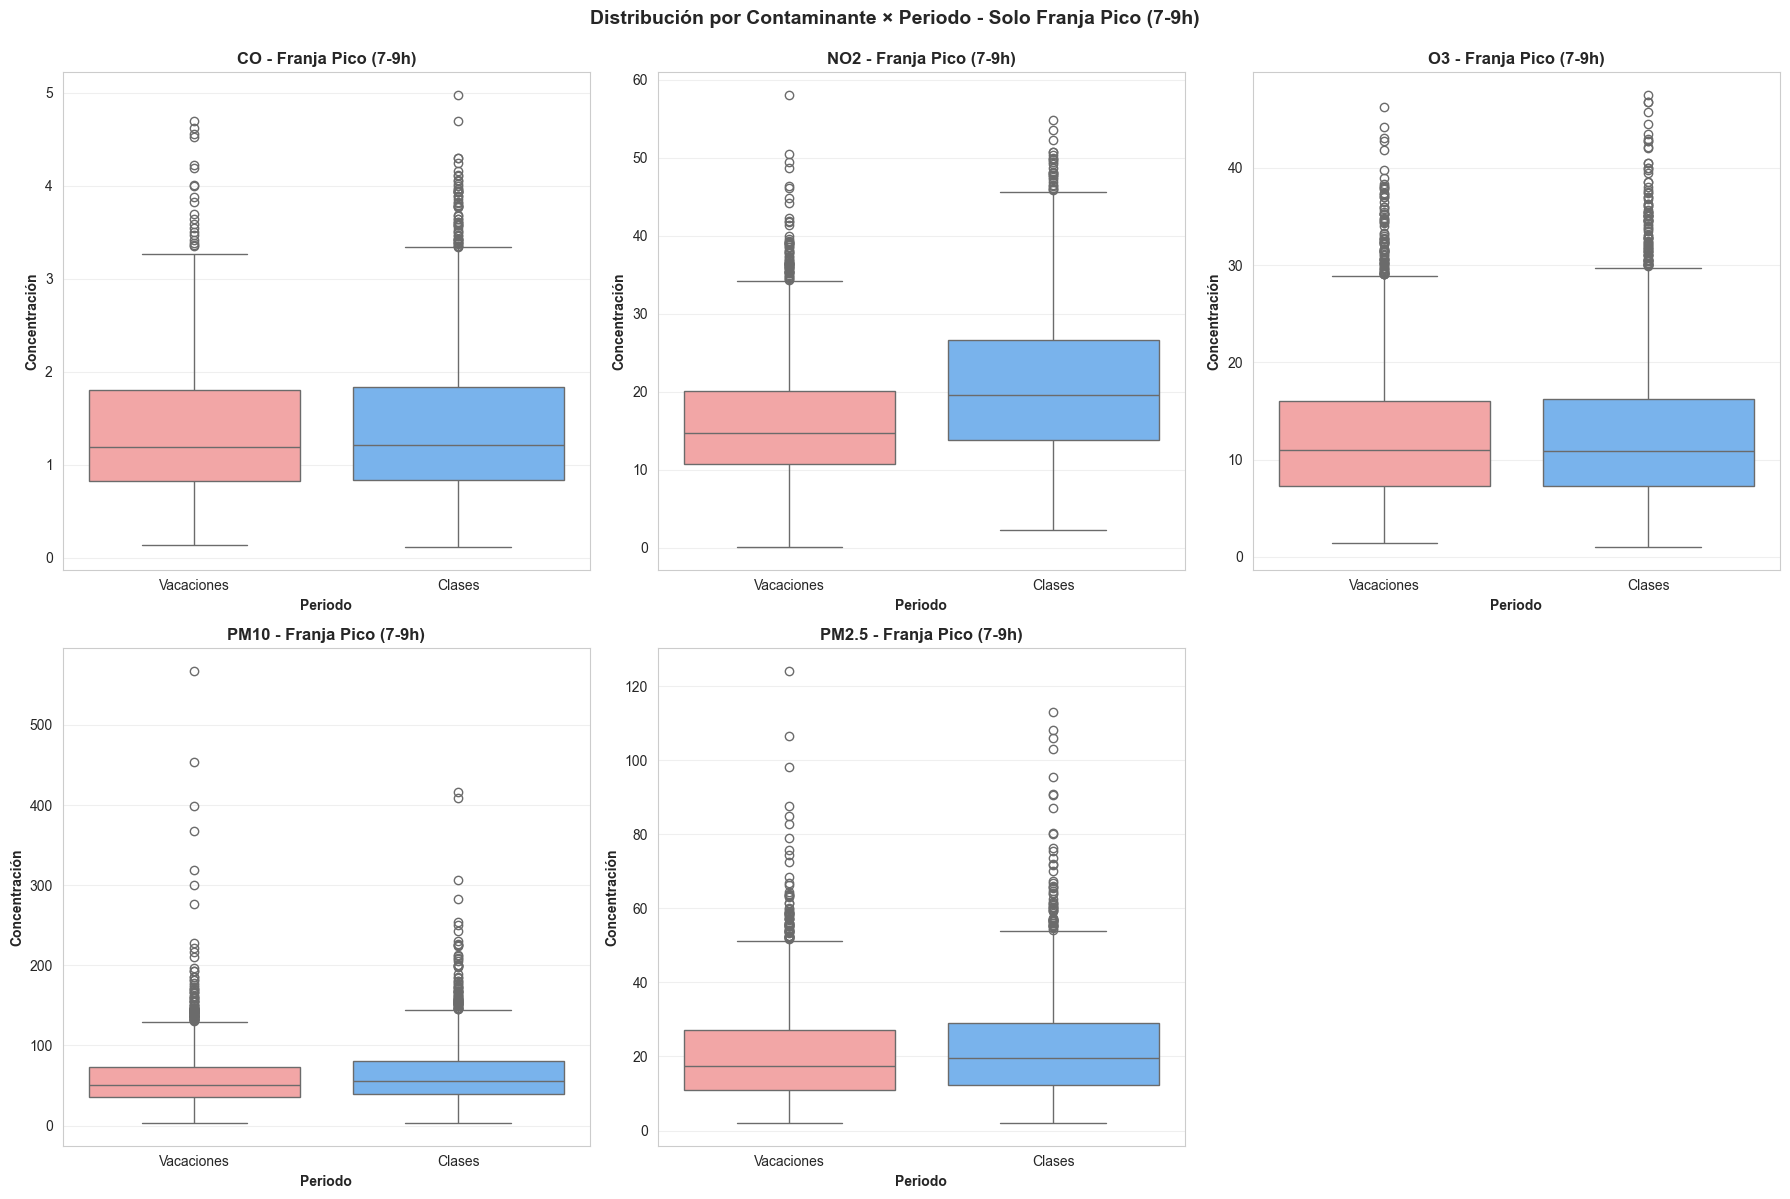

In [57]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

parametros_sorted_pico = sorted(df_pico['parametro'].unique())

for idx, param in enumerate(parametros_sorted_pico):
    data_param = df_pico[df_pico['parametro'] == param]
    
    sns.boxplot(data=data_param, x='clase', y='valor', 
                palette=['#ff9999', '#66b3ff'], ax=axes[idx])
    
    axes[idx].set_title(f'{param} - Franja Pico (7-9h)', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Periodo', fontsize=10, fontweight='bold')
    axes[idx].set_ylabel('Concentración', fontsize=10, fontweight='bold')
    axes[idx].grid(axis='y', alpha=0.3)
    axes[idx].set_xticklabels(['Vacaciones', 'Clases'])

# Ocultar ejes extras
for idx in range(len(parametros_sorted_pico), len(axes)):
    axes[idx].axis('off')

plt.suptitle('Distribución por Contaminante × Periodo - Solo Franja Pico (7-9h)', 
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

### 15.12 Matriz de correlación entre contaminantes

In [58]:
# Crear tabla pivot para correlación
pivot_pico = df_pico.pivot_table(
    index='date', 
    columns='parametro', 
    values='valor', 
    aggfunc='mean'
)

print("=" * 70)
print("TABLA PIVOT - SOLO FRANJA PICO (7-9h)")
print("=" * 70)
print(f"Forma de la tabla: {pivot_pico.shape}")
print(f"Fechas únicas: {len(pivot_pico)}")
print(f"Contaminantes: {list(pivot_pico.columns)}")
print("=" * 70)

# Calcular correlación
contaminantes_interes_pico = ['CO', 'NO2', 'PM10', 'PM2.5', 'O3']
correlacion_pico = pivot_pico[contaminantes_interes_pico].corr()

print("\n" + "=" * 70)
print("MATRIZ DE CORRELACIÓN ENTRE CONTAMINANTES - FRANJA PICO (7-9h)")
print("=" * 70)
print(correlacion_pico.round(3))
print("=" * 70)

# Estadísticas de correlación
print("\nEstadísticas de correlación:")
print(f"  • Correlación promedio: {correlacion_pico.values[np.triu_indices_from(correlacion_pico.values, k=1)].mean():.3f}")
print(f"  • Correlación máxima: {correlacion_pico.values[np.triu_indices_from(correlacion_pico.values, k=1)].max():.3f}")
print(f"  • Correlación mínima: {correlacion_pico.values[np.triu_indices_from(correlacion_pico.values, k=1)].min():.3f}")

# Pares con mayor correlación
print("\nPares con mayor correlación en franja pico:")
corr_pairs_pico = []
for i in range(len(correlacion_pico.columns)):
    for j in range(i+1, len(correlacion_pico.columns)):
        corr_pairs_pico.append((correlacion_pico.columns[i], correlacion_pico.columns[j], correlacion_pico.iloc[i, j]))
corr_pairs_sorted_pico = sorted(corr_pairs_pico, key=lambda x: abs(x[2]), reverse=True)
for par1, par2, corr_val in corr_pairs_sorted_pico[:5]:
    print(f"  • {par1} - {par2}: {corr_val:.3f}")

TABLA PIVOT - SOLO FRANJA PICO (7-9h)
Forma de la tabla: (912, 5)
Fechas únicas: 912
Contaminantes: ['CO', 'NO2', 'O3', 'PM10', 'PM2.5']

MATRIZ DE CORRELACIÓN ENTRE CONTAMINANTES - FRANJA PICO (7-9h)
parametro     CO    NO2   PM10  PM2.5     O3
parametro                                   
CO         1.000  0.455  0.459  0.526 -0.123
NO2        0.455  1.000  0.589  0.449 -0.372
PM10       0.459  0.589  1.000  0.749 -0.205
PM2.5      0.526  0.449  0.749  1.000 -0.270
O3        -0.123 -0.372 -0.205 -0.270  1.000

Estadísticas de correlación:
  • Correlación promedio: 0.226
  • Correlación máxima: 0.749
  • Correlación mínima: -0.372

Pares con mayor correlación en franja pico:
  • PM10 - PM2.5: 0.749
  • NO2 - PM10: 0.589
  • CO - PM2.5: 0.526
  • CO - PM10: 0.459
  • CO - NO2: 0.455


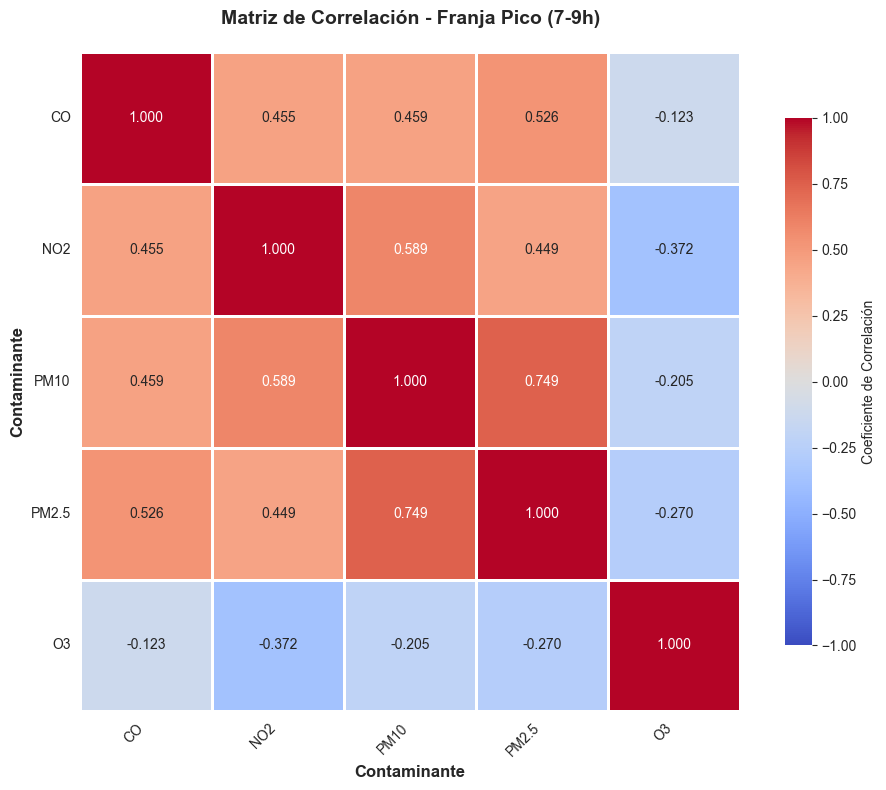

In [59]:
# Heatmap de correlación - Solo pico
fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(correlacion_pico, 
            annot=True,
            fmt='.3f',
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=1,
            cbar_kws={'label': 'Coeficiente de Correlación', 'shrink': 0.8},
            vmin=-1, 
            vmax=1,
            ax=ax)

ax.set_title('Matriz de Correlación - Franja Pico (7-9h)', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Contaminante', fontsize=12, fontweight='bold')
ax.set_ylabel('Contaminante', fontsize=12, fontweight='bold')

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

### 15.13 Análisis de simetría y forma de distribución

In [60]:
from scipy import stats

print("=" * 80)
print("ANÁLISIS DE SIMETRÍA - SOLO FRANJA PICO (7-9h)")
print("=" * 80)

resultados_simetria_pico = []

for param in sorted(df_pico['parametro'].unique()):
    datos_param = df_pico[df_pico['parametro'] == param]['valor']
    
    skewness = stats.skew(datos_param)
    kurtosis = stats.kurtosis(datos_param, fisher=False)
    
    # Interpretar skewness
    if abs(skewness) < 0.5:
        interp_skew = "Simétrica"
    elif skewness > 0:
        interp_skew = "Asimétrica positiva"
    else:
        interp_skew = "Asimétrica negativa"
    
    # Interpretar kurtosis
    if 2.5 < kurtosis < 3.5:
        interp_kurt = "Normal"
    elif kurtosis > 3.5:
        interp_kurt = "Leptocúrtica"
    else:
        interp_kurt = "Platicúrtica"
    
    resultados_simetria_pico.append({
        'Contaminante': param,
        'Skewness': round(skewness, 3),
        'Interpretación': interp_skew,
        'Kurtosis': round(kurtosis, 3),
        'Forma': interp_kurt
    })

df_simetria_pico = pd.DataFrame(resultados_simetria_pico)
print(df_simetria_pico.to_string(index=False))
print("=" * 80)

ANÁLISIS DE SIMETRÍA - SOLO FRANJA PICO (7-9h)
Contaminante  Skewness      Interpretación  Kurtosis        Forma
          CO     1.018 Asimétrica positiva     3.849 Leptocúrtica
         NO2     0.802 Asimétrica positiva     3.458       Normal
          O3     1.186 Asimétrica positiva     4.624 Leptocúrtica
        PM10     2.630 Asimétrica positiva    22.185 Leptocúrtica
       PM2.5     1.432 Asimétrica positiva     7.123 Leptocúrtica


### 15.14 Resumen comparativo: Media y Varianza por contaminante

In [61]:
print("\n" + "="*90)
print("RESUMEN COMPARATIVO - MEDIA Y VARIANZA POR CONTAMINANTE (FRANJA PICO 7-9h)")
print("="*90)

resumen_pico = df_pico.groupby('parametro')['valor'].agg(['mean', 'var', 'std', 'min', 'max']).round(3)
resumen_pico.columns = ['Media', 'Varianza', 'Desv. Estándar', 'Mínimo', 'Máximo']
resumen_pico = resumen_pico.sort_values('Media', ascending=False)

print(resumen_pico.to_string())
print("="*90)

# Coeficiente de variación
cv_pico = (resumen_pico['Desv. Estándar'] / resumen_pico['Media'] * 100).round(2)
print("\nCoeficiente de Variación (CV) por contaminante:")
print("(Indica variabilidad relativa: CV alto = más dispersión)")
print("-" * 90)
for param in cv_pico.sort_values(ascending=False).index:
    print(f"  {param:8s}:  {cv_pico[param]:6.2f}%")
print("="*90)


RESUMEN COMPARATIVO - MEDIA Y VARIANZA POR CONTAMINANTE (FRANJA PICO 7-9h)
            Media  Varianza  Desv. Estándar  Mínimo   Máximo
parametro                                                   
PM10       60.486  1260.548          35.504   3.000  567.333
PM2.5      21.173   165.785          12.876   2.000  124.100
NO2        18.462    74.427           8.627   0.100   58.075
O3         12.532    52.296           7.232   1.000   47.500
CO          1.394     0.520           0.721   0.115    4.975

Coeficiente de Variación (CV) por contaminante:
(Indica variabilidad relativa: CV alto = más dispersión)
------------------------------------------------------------------------------------------
  PM2.5   :   60.81%
  PM10    :   58.70%
  O3      :   57.71%
  CO      :   51.72%
  NO2     :   46.73%


### 15.15 Gráficos comparativos: Media y Varianza

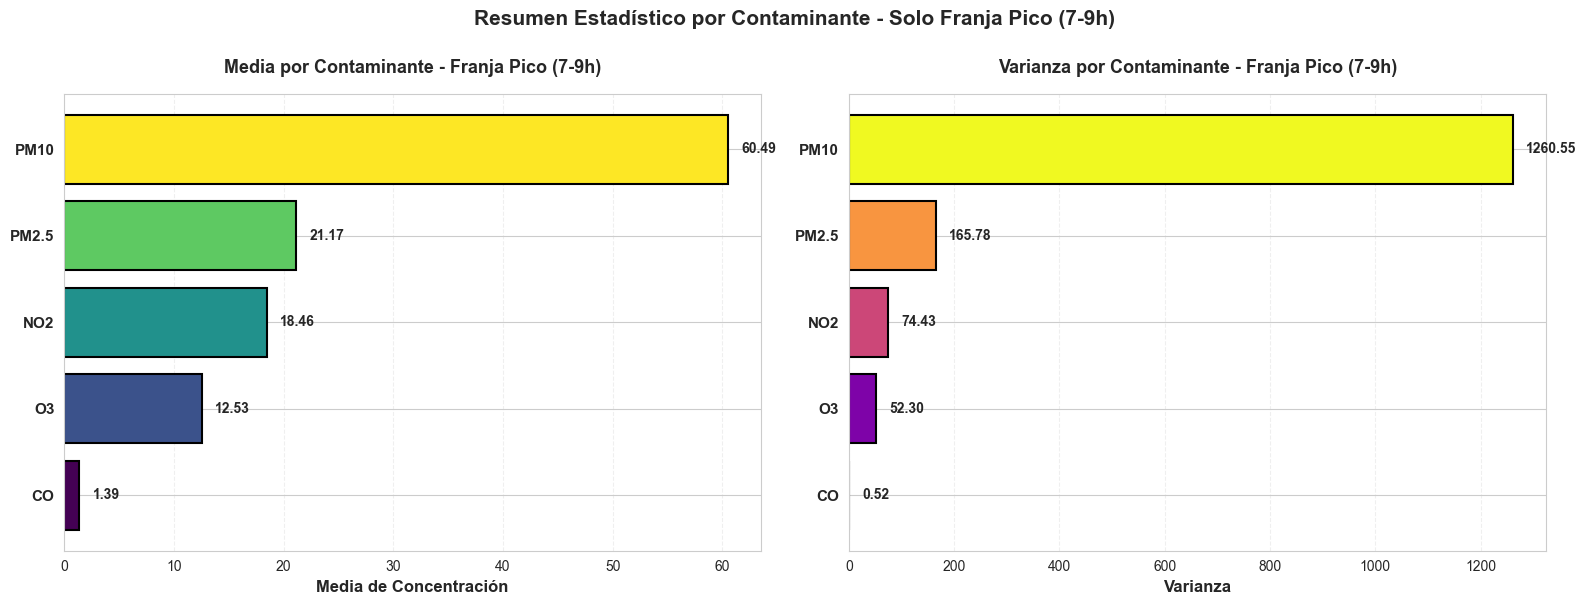

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Media por contaminante
ax1 = axes[0]
resumen_pico_sorted = resumen_pico.sort_values('Media', ascending=True)
colors_media = plt.cm.viridis(np.linspace(0, 1, len(resumen_pico_sorted)))
bars1 = ax1.barh(range(len(resumen_pico_sorted)), resumen_pico_sorted['Media'], 
                 color=colors_media, edgecolor='black', linewidth=1.5)
ax1.set_yticks(range(len(resumen_pico_sorted)))
ax1.set_yticklabels(resumen_pico_sorted.index, fontsize=11, fontweight='bold')
ax1.set_xlabel('Media de Concentración', fontsize=12, fontweight='bold')
ax1.set_title('Media por Contaminante - Franja Pico (7-9h)', fontsize=13, fontweight='bold', pad=15)
ax1.grid(axis='x', alpha=0.3, linestyle='--')

# Añadir valores en las barras
for idx, (val, bar) in enumerate(zip(resumen_pico_sorted['Media'], bars1)):
    ax1.text(val + max(resumen_pico_sorted['Media'])*0.02, idx, f'{val:.2f}', 
             va='center', fontsize=10, fontweight='bold')

# Gráfico 2: Varianza por contaminante
ax2 = axes[1]
resumen_pico_var_sorted = resumen_pico.sort_values('Varianza', ascending=True)
colors_var = plt.cm.plasma(np.linspace(0, 1, len(resumen_pico_var_sorted)))
bars2 = ax2.barh(range(len(resumen_pico_var_sorted)), resumen_pico_var_sorted['Varianza'], 
                 color=colors_var, edgecolor='black', linewidth=1.5)
ax2.set_yticks(range(len(resumen_pico_var_sorted)))
ax2.set_yticklabels(resumen_pico_var_sorted.index, fontsize=11, fontweight='bold')
ax2.set_xlabel('Varianza', fontsize=12, fontweight='bold')
ax2.set_title('Varianza por Contaminante - Franja Pico (7-9h)', fontsize=13, fontweight='bold', pad=15)
ax2.grid(axis='x', alpha=0.3, linestyle='--')

# Añadir valores en las barras
for idx, (val, bar) in enumerate(zip(resumen_pico_var_sorted['Varianza'], bars2)):
    ax2.text(val + max(resumen_pico_var_sorted['Varianza'])*0.02, idx, f'{val:.2f}', 
             va='center', fontsize=10, fontweight='bold')

plt.suptitle('Resumen Estadístico por Contaminante - Solo Franja Pico (7-9h)', 
             fontsize=15, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

### 15.15 Gráficos de barras y pastel

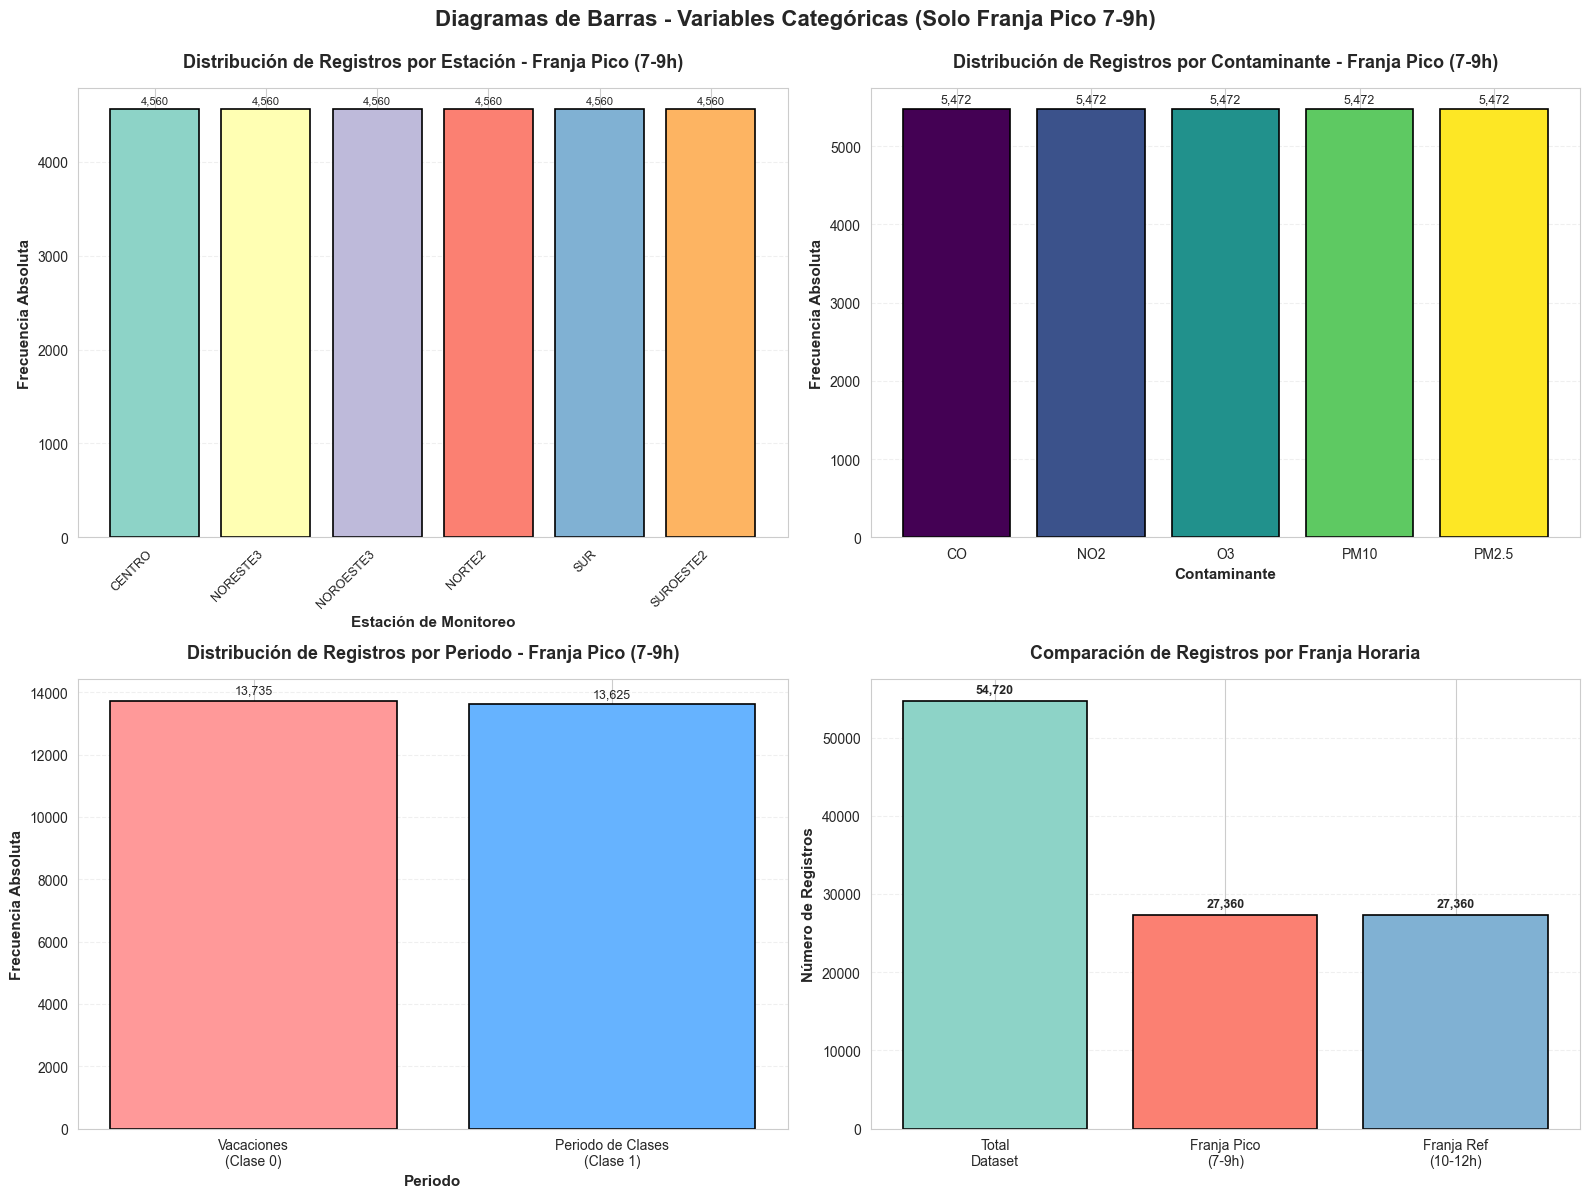

In [63]:
# Gráficos de barras para variables categóricas - Solo franja pico (7-9h)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Frecuencia por Estación
ax1 = axes[0, 0]
freq_est_pico = df_pico['estacion'].value_counts().sort_index()
colors_est = plt.cm.Set3(range(len(freq_est_pico)))
ax1.bar(range(len(freq_est_pico)), freq_est_pico.values, color=colors_est, edgecolor='black', linewidth=1.2)
ax1.set_xticks(range(len(freq_est_pico)))
ax1.set_xticklabels(freq_est_pico.index, rotation=45, ha='right', fontsize=9)
ax1.set_ylabel('Frecuencia Absoluta', fontsize=11, fontweight='bold')
ax1.set_xlabel('Estación de Monitoreo', fontsize=11, fontweight='bold')
ax1.set_title('Distribución de Registros por Estación - Franja Pico (7-9h)', fontsize=13, fontweight='bold', pad=15)
ax1.grid(axis='y', alpha=0.3, linestyle='--')
for i, v in enumerate(freq_est_pico.values):
    ax1.text(i, v + max(freq_est_pico.values)*0.01, f'{v:,}', ha='center', va='bottom', fontsize=8)

# 2. Frecuencia por Parámetro
ax2 = axes[0, 1]
freq_param_pico = df_pico['parametro'].value_counts().sort_index()
colors_param = plt.cm.viridis(np.linspace(0, 1, len(freq_param_pico)))
ax2.bar(range(len(freq_param_pico)), freq_param_pico.values, color=colors_param, edgecolor='black', linewidth=1.2)
ax2.set_xticks(range(len(freq_param_pico)))
ax2.set_xticklabels(freq_param_pico.index, fontsize=10)
ax2.set_ylabel('Frecuencia Absoluta', fontsize=11, fontweight='bold')
ax2.set_xlabel('Contaminante', fontsize=11, fontweight='bold')
ax2.set_title('Distribución de Registros por Contaminante - Franja Pico (7-9h)', fontsize=13, fontweight='bold', pad=15)
ax2.grid(axis='y', alpha=0.3, linestyle='--')
for i, v in enumerate(freq_param_pico.values):
    ax2.text(i, v + max(freq_param_pico.values)*0.01, f'{v:,}', ha='center', va='bottom', fontsize=9)

# 3. Frecuencia por Clase
ax3 = axes[1, 0]
freq_clase_pico = df_pico['clase'].value_counts().sort_index()
colors_clase = ['#ff9999', '#66b3ff']
ax3.bar(range(len(freq_clase_pico)), freq_clase_pico.values, color=colors_clase, edgecolor='black', linewidth=1.2)
ax3.set_xticks(range(len(freq_clase_pico)))
etiquetas_clase = ['Vacaciones\n(Clase 0)', 'Periodo de Clases\n(Clase 1)']
ax3.set_xticklabels(etiquetas_clase, fontsize=10)
ax3.set_ylabel('Frecuencia Absoluta', fontsize=11, fontweight='bold')
ax3.set_xlabel('Periodo', fontsize=11, fontweight='bold')
ax3.set_title('Distribución de Registros por Periodo - Franja Pico (7-9h)', fontsize=13, fontweight='bold', pad=15)
ax3.grid(axis='y', alpha=0.3, linestyle='--')
for i, v in enumerate(freq_clase_pico.values):
    ax3.text(i, v + max(freq_clase_pico.values)*0.01, f'{v:,}', ha='center', va='bottom', fontsize=9)

# 4. Comparación Total de Registros
ax4 = axes[1, 1]
total_original = len(df)
total_pico = len(df_pico)
total_ref = len(df) - len(df_pico)
ax4.bar(['Total\nDataset', 'Franja Pico\n(7-9h)', 'Franja Ref\n(10-12h)'], 
        [total_original, total_pico, total_ref],
        color=['#8dd3c7', '#fb8072', '#80b1d3'], 
        edgecolor='black', linewidth=1.2)
ax4.set_ylabel('Número de Registros', fontsize=11, fontweight='bold')
ax4.set_title('Comparación de Registros por Franja Horaria', fontsize=13, fontweight='bold', pad=15)
ax4.grid(axis='y', alpha=0.3, linestyle='--')
for i, v in enumerate([total_original, total_pico, total_ref]):
    ax4.text(i, v + max([total_original, total_pico, total_ref])*0.01, f'{v:,}', 
             ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('Diagramas de Barras - Variables Categóricas (Solo Franja Pico 7-9h)', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

### 15.16 Resumen de hallazgos clave

In [64]:
print("\n" + "="*90)
print("HALLAZGOS CLAVE - ANÁLISIS EXPLORATORIO FRANJA PICO (7-9h)")
print("="*90)

print("\n1. ESTACIÓN CON MAYOR CONTAMINACIÓN PROMEDIO:")
print(stats_pico_estacion['media'].sort_values(ascending=False).head(3).to_string())

print("\n2. CONTAMINANTE CON MAYOR CONCENTRACIÓN PROMEDIO:")
print(stats_pico_parametro['media'].sort_values(ascending=False).to_string())

print("\n3. DIFERENCIA ENTRE PERIODOS DE CLASES Y VACACIONES:")
diff_clase = stats_pico_clase.loc[1, 'media'] - stats_pico_clase.loc[0, 'media']
pct_diff = (diff_clase / stats_pico_clase.loc[0, 'media']) * 100
print(f"   • Vacaciones (Clase 0):       {stats_pico_clase.loc[0, 'media']:.2f}")
print(f"   • Periodo de clases (Clase 1): {stats_pico_clase.loc[1, 'media']:.2f}")
print(f"   • Diferencia:                  {diff_clase:.2f} ({pct_diff:+.2f}%)")

print("\n4. VARIABILIDAD POR CONTAMINANTE (Coef. de Variación):")
for param, cv_val in cv_pico.sort_values(ascending=False).head(5).items():
    print(f"   • {param:8s}: {cv_val:6.2f}%")

print("\n5. CONTAMINANTE MÁS ESTABLE (menor variabilidad):")
print(f"   • {cv_pico.idxmin()}: {cv_pico.min():.2f}%")

print("\n6. ESTACIONES CON MAYOR VARIABILIDAD:")
cv_estacion_pico = (stats_pico_estacion['desv_std'] / stats_pico_estacion['media'] * 100).sort_values(ascending=False)
for est, cv_val in cv_estacion_pico.head(3).items():
    print(f"   • {est}: {cv_val:.2f}%")

print("\n" + "="*90)


HALLAZGOS CLAVE - ANÁLISIS EXPLORATORIO FRANJA PICO (7-9h)

1. ESTACIÓN CON MAYOR CONTAMINACIÓN PROMEDIO:
estacion
SUROESTE2    24.687329
CENTRO       24.382394
NORTE2       23.684994

2. CONTAMINANTE CON MAYOR CONCENTRACIÓN PROMEDIO:
parametro
PM10     60.486420
PM2.5    21.172576
NO2      18.461564
O3       12.531632
CO        1.393513

3. DIFERENCIA ENTRE PERIODOS DE CLASES Y VACACIONES:
   • Vacaciones (Clase 0):       21.62
   • Periodo de clases (Clase 1): 24.01
   • Diferencia:                  2.39 (+11.07%)

4. VARIABILIDAD POR CONTAMINANTE (Coef. de Variación):
   • PM2.5   :  60.81%
   • PM10    :  58.70%
   • O3      :  57.71%
   • CO      :  51.72%
   • NO2     :  46.73%

5. CONTAMINANTE MÁS ESTABLE (menor variabilidad):
   • NO2: 46.73%

6. ESTACIONES CON MAYOR VARIABILIDAD:
   • NORTE2: 122.50%
   • NORESTE3: 121.16%
   • NOROESTE3: 120.35%

